# 150,000 bankroll with a 25% pool cap

> **Re-verified 2026-08-07** against trade-executor [#1621](https://github.com/tradingstrategy-ai/trade-executor/pull/1621) (Hypercore dust-close unit fix). All four cells reproduce their published numbers exactly, and the accounting audit confirms every cell coherent - residual -0.16% to -0.01%, 0 destroyed positions. The 150k/15% near-collapse at 6.31% CAGR is a genuine capacity result, not an artefact.

Based on `66-backtest-softband-250-500.ipynb`, itself a variant of the release candidate
`65-candidate-backtest-2d-cadence-fee-drag-mitigation.ipynb`. Three changes:

1. **150,000 USD bankroll**, 6x the release candidate's 25,000 and 2x NB66's 75,000.
2. **25% pool cap** (`per_position_cap_of_pool_pct`), raised from the 15% used everywhere else in
   this chain.
3. **Sell-side softband fixed at 0.5% of capital, $750** - chosen rather than searched, see below.

Everything else is the release candidate: native 2-day cycle, 6-vault basket, 33% concentration
ceiling, 10 BPS redemption fee, composite CAGR+Sharpe selection, 14-day momentum gate, 60-day
inverse-vol sizing, window 2026-01-01 to 2026-07-10.

## Why these three

NB66 found the first capacity limit for this strategy at 75,000 with a 15% pool cap. Half the
six-vault basket was pool-capped in the average cycle, 11 of 95 cycles left more than 10% of
investable capital unplaced, and **drawdown degraded from -5.65% to -7.07%** even though CAGR held
up. That raised a question the fee work could not answer: is the binding constraint the capital or
the cap?

This notebook doubles the capital again and loosens the cap at the same time. At 150,000 a 33%
concentration ceiling wants up to $49,500 in a single vault, which a 15% cap only permits for vaults
above $330,000 of TVL; a 25% cap brings that threshold down to $198,000 and lets much more of the
Hyperliquid universe carry a full-sized position.

## Why 0.5% for the softband

NB66 swept the band across two bankrolls and settled three things:

- **It cannot recover fee drag at any width.** It removes ~56% of trims and ~1% of redemption
  volume, because full exits carry ~70% of that volume and no trim threshold touches them.
- **The crash boundary is a fraction of capital, not a dollar amount**: between **1% and 2%** at
  both 25,000 and 75,000, from a defect where suppressed sells are not deducted from the buy budget.
- **The 1% rung is the edge**, not a safe margin - it completed on one window and crashed on another
  at 25,000.

So the band here is set to remove unnecessary rebalancing rather than to save fee: **0.5% drops
about 43% of trims while sitting a factor of four below the failure boundary.** The sweep section
re-tests 1%, 2% and 4% to confirm the boundary has not moved under the looser pool cap - the two
interact, since a larger permitted position means larger trims.

## Key new insights and what did we learn from this experiment?

### The pool cap is a real constraint, and 25% is a clear improvement at today's size

The 2x2 over capital and cap, at a fixed 0.5% softband and 2-day cadence:

| | 15% pool cap | 25% pool cap |
|---|---|---|
| **75,000** | 35.13% CAGR, -7.08% DD, 3.06 capped signals | **39.74% CAGR, -6.32% DD, 1.84 capped** |
| **150,000** | 6.31% CAGR, -13.31% DD, 3.86 capped | 26.65% CAGR, -7.93% DD, 3.32 capped |

| Change | CAGR effect |
|---|---:|
| Raise the cap 15% -> 25%, at 75,000 | **+4.61 pp** |
| Raise the cap 15% -> 25%, at 150,000 | **+20.34 pp** |
| Double capital 75k -> 150k, at a 15% cap | **-28.82 pp** |
| Double capital 75k -> 150k, at a 25% cap | **-13.09 pp** |
| Both together | -8.48 pp |

**The best cell in the whole grid is 75,000 at a 25% cap** - 39.74% CAGR, -6.32% drawdown, Sharpe
1.90, and pool-capped signals almost halved from 3.06 to 1.84 per cycle. Raising the cap improves
return *and* drawdown *and* turnover simultaneously at the release candidate's own scale, which is
the rare kind of change that is not a trade-off.

That is the actionable finding here, and it is independent of the 150,000 question.

### Capital is the dominant constraint, and 150,000 is past the edge

Doubling capital costs between 13 and 29 percentage points of CAGR depending on the cap. At
150,000 with the chain's standard 15% cap the strategy **very nearly collapses**: 6.31% CAGR and a
-13.31% drawdown, against 35.13% and -7.08% at half the size. Turnover falls from 11.6x to 8.6x -
the strategy simply cannot place the money.

Raising the cap to 25% rescues most of that (26.65% CAGR, -7.93% drawdown) but **does not restore
it to the 75,000 level**. So the cap is worth loosening, and loosening it does not make the strategy
scale to 150,000 on this universe.

The two levers interact strongly: the cap is worth +4.61 pp at 75,000 and +20.34 pp at 150,000. It
matters more the more capital you have, which is exactly what a binding capacity constraint looks
like.

**The capacity ceiling for this strategy sits between 75,000 and 150,000** on the 2026 Hyperliquid
universe. Even at 150,000 with the looser cap, the deployment diagnostics show 3.82% of investable
capital unplaced on average, 13 of 95 cycles leaving more than 10% unplaced, and one cycle
(2026-06-02) holding 38.5% cash.

### The softband choice was right, and 1% is now clearly harmful

The band was set at 0.5% of capital rather than searched, on NB66's evidence. The sweep confirms it:

| Band | % of capital | CAGR | Trims removed | Volume removed | Fee saved | Max DD |
|---:|---:|---:|---:|---:|---:|---:|
| $5 | floor | 26.81% | - | - | - | -7.88% |
| **$750** | **0.5%** | **26.65%** | **-46.0%** | -0.5% | $8 | -7.93% |
| $1,500 | 1.0% | 25.90% | -59.8% | -1.1% | $19 | -8.14% |
| $3,000 | 2.0% | *crash* | | | | |

0.5% buys a 46% cut in trims for -0.16 pp of CAGR. **1% costs -0.91 pp** - the largest penalty
measured at any bankroll, and it worsens drawdown too. At 25,000 the 1% rung looked like a
coin-flip; at 150,000 it is simply bad.

The fee story is unchanged and now measured at a third bankroll: 64 exits carry **70.3%** of
redemption volume, so **$1,164 of the $1,656 fee is untouchable** by any trim threshold.

### The crash boundary is unchanged by the pool cap

2% and 4% still fail; 0.5% and 1% still complete, on both the full window and the daily sub-window.
Loosening the pool cap permits larger positions and therefore larger trims, which could have moved
the boundary - it did not. Worth noting the 2% failure is now marginal: it dies **$48.04** short on
a $150,000 bankroll, so the boundary is genuinely close to 2% rather than comfortably beyond it.

## Summary of results

Headline configuration: **150,000 bankroll, 25% pool cap, 0.5% softband ($750), 2-day cadence,
33% concentration, 10 BPS fee, 2026-01-01 to 2026-07-10.**

| Metric | This notebook | 75k / 25% cap | 75k / 15% cap (NB66) |
|---|---:|---:|---:|
| Final equity | $169,244 | $89,019 | $87,494 |
| Cumulative return | 12.83% | **18.69%** | 16.66% |
| CAGR | 26.65% | **39.74%** | 35.13% |
| Sharpe | 1.41 | **1.90** | 1.81 |
| Max drawdown | -7.93% | **-6.32%** | -7.08% |
| Mean pool-capped signals per cycle | 3.32 | **1.84** | 3.06 |
| Redemption turnover | 11.0x | 12.4x | 11.6x |

Fee A/B at the headline configuration: **$171,018 at 0 BPS against $169,244 at 10 BPS**, a drag of
-1.18% of final equity and **-2.34 pp of CAGR**, against $1,648 of fee paid.

**The recommendation from this notebook is not the headline configuration.** It is to raise the pool
cap to 25% at the release candidate's current 25,000-75,000 scale, and to treat 150,000 as beyond
capacity on this universe.

## Robustness of results

- **The 2x2 is internally consistent**: same window, same universe, same indicator set, same code
  path, with every capital-derived threshold scaled. It is the cleanest comparison in this chain
  because nothing varies except the two levers under test.
- **`Mean cash %` is blank in the 2x2 table** - the allocation parser did not populate that column
  for those runs. Pool-capped signal counts did populate and carry the same message; the headline
  run's cash figures come from the deployment diagnostics cell instead.
- **The 150,000 / 15% cell is a single configuration on a single window**, and a 6.31% CAGR with a
  -13.31% drawdown is a large claim to rest on one run. The direction is corroborated by the
  monotone deployment statistics across 25k, 75k and 150k, but the magnitude should not be quoted
  precisely.
- **Capacity is a moving target.** These figures reflect Hyperliquid vault TVL in the first half of
  2026. A universe that grows raises the ceiling; one that contracts lowers it. Any capacity number
  from this notebook needs re-measuring before it is used for allocation decisions.
- **Deposit windows bind as well as pool caps**: 38 cycles skipped closed-window candidates at
  selection, 74 candidates in total, and 7 cycles had a `cannot_deposit` signal. Some of the
  undeployed cash is a deposit-availability problem, not a TVL problem, and the two are not
  separated here.
- **Return is concentrated but less extreme than at smaller size**: neutralising the largest 5% of
  profitable days cuts CAGR from 26.65% to 5.35%, but excess kurtosis is **4.56** against 11.02 at
  25,000, and skew is +0.16 against -0.99. Spreading capital across more, smaller positions has
  made the daily return distribution better behaved even as the mean fell.
- **Best day +3.28% on 2026-07-04**, 6.5% of all positive return - the same market-wide 2-day move
  NB65 verified against BTC (+2.6%) and ETH (+4.7%), not a single lucky trade.
- Same data caveats as the rest of the chain: window opens 2026-01-01, January 2026 is 55% covered,
  the Hypercore feed is weekly before 2026-01-17. The sub-window sweep bounds this.

## What to do about it

1. **Raise `per_position_cap_of_pool_pct` to 0.25 in the release candidate.** At 75,000 it is worth
   +4.61 pp of CAGR, 0.76 pp of drawdown and halves the pool-capped signal count. This is the
   change to take forward from this notebook.
2. **Do not run this strategy at 150,000 on the current universe.** It is past capacity: a third of
   the return disappears even with the looser cap, and at the standard 15% cap it fails outright.
3. **Establish the ceiling properly** with a capital ladder at 25k / 50k / 75k / 100k / 125k, at a
   25% cap. This notebook brackets it between 75,000 and 150,000; that is too wide to allocate
   against.
4. **Keep the softband at 0.5% of capital** if trim suppression is wanted, and never at 1% or above.
   Its purpose is fewer pointless rebalances, not fee saving.
5. **Separate the deposit-window constraint from the TVL constraint** before concluding that TVL is
   the binding capacity limit - 38 cycles skipped candidates for closed deposit windows.


## Notebook setup

- Shared imports, chart output settings, and notebook logging for the clean-up variant.

In [1]:
import datetime
import logging

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

- Use the same Hyperliquid survivor-first vault universe as NB152 so the clean-up stays directly comparable.

In [2]:
from eth_defi.token import USDC_NATIVE_TOKEN
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.hyperliquid

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.hyperliquid.value,
    address=USDC_NATIVE_TOKEN[ChainId.hyperliquid].lower(),
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: HyperEVM
Reserve asset: <USDC at 0xb88339cb7199b77e23db6e890353e22632ba630f>


## Parameters

- Keep the strategy parameters identical to `02-backtest-until-2026-07-09.ipynb`, except reduce initial capital to `25,000 USD`.


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters
from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier.
    id = '67-backtest-150k-pool-cap-25pct'

    #: Daily candles match the whole Hyperliquid survivor-first research chain.
    candle_time_bucket = TimeBucket.d1
    #: Two-day rebalance cadence, the NB63/NB64 recommendation, expressed natively: the engine
    #: steps every 48 hours. NB64 reached the same schedule by running a sub-daily clock and
    #: skipping cycles with a modulo counter; this notebook does not, so there is no gap between
    #: what the parameter says and what the engine does.
    #:
    #: Passed explicitly to `run_backtest_inline()` below. The inherited call site derived the
    #: cycle from `candle_time_bucket` instead, which would silently ignore this value.
    cycle_duration = CycleDuration.cycle_2d
    #: HyperEVM is the primary chain for vaults.
    chain_id = CHAIN_ID
    #: HyperEVM is the primary execution chain.
    primary_chain_id = CHAIN_ID
    #: Same exchange set as the release-candidate notebooks.
    exchanges = EXCHANGES

    #: Six-vault basket per the NB35 breadth study: one slot wider than the NB29 #48
    #: optimum. Halves max drawdown vs 5 vaults by keeping fresh-entry blow-ups (IKAGI,
    #: 2026-06-17) position-sized, at a ~4.5pp CAGR cost.
    max_assets_in_portfolio = 6
    #: 98% target deployment, the validated release default.
    allocation_pct = 0.98
    #: Concentration ceiling per position. NB53 moved this from NB36's 0.50 to 0.35 and NB63/NB64
    #: pinned 0.35; 0.33 is a round third, so a six-vault basket needs at least three positions
    #: carrying weight before the cap stops binding.
    #:
    #: NB65's reconciliation measured 0.50 -> 0.35 as worth +5.25 pp of CAGR on this strategy, so
    #: this is the single largest non-cadence lever in the notebook.
    max_concentration_pct = 0.33
    #: Cap position size to this share of vault TVL, raised from the 0.15 used everywhere else in
    #: this chain. At 150,000 a 33% concentration ceiling wants up to $49,500 in one vault, which a
    #: 15% cap only permits for vaults above $330,000 of TVL; a 25% cap brings that down to
    #: $198,000 and lets far more of the universe take a full-sized position.
    #:
    #: This is the lever under test. NB31 showed that removing the cap entirely *hurts* returns, so
    #: 0.25 is a loosening rather than an abandonment: the backtest still does not assume the
    #: strategy can own an unrealistic share of any vault.
    per_position_cap_of_pool_pct = 0.25
    #: Engine hygiene threshold for cleaning up tiny residual positions.
    min_portfolio_weight_pct = 0.005

    #: Hyperliquid has a hard 5 USD minimum deposit.
    absolute_min_vault_deposit_usd = 5.0
    #: Buy threshold as a fraction of initial cash.
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    #: Sell threshold as a fraction of initial cash: **0.5%**, i.e. $750 at this bankroll.
    #: NB62 measured 543 weight-drift trims worth $263k against 99 exits; the softband
    #: suppresses the trims, which are the cheapest turnover to give up.
    #:
    #: Chosen, not searched. NB66 swept the band at two bankrolls and established three things:
    #: the band cannot recover meaningful fee drag at any width (it removes ~56% of trims and ~1% of
    #: redemption volume, because full exits carry ~70% of that volume and no trim threshold
    #: touches them); the crash boundary sits between **1% and 2% of capital** at both 25,000 and
    #: 75,000; and the 1% rung is the *edge* - it completed on one window and crashed on another at
    #: 25,000.
    #:
    #: So 0.5% is picked to remove unnecessary rebalancing rather than to save fee: it drops ~43% of
    #: trims while sitting a factor of four below the failure boundary instead of on it. The sweep
    #: below re-tests 1%, 2% and 4% to confirm the boundary has not moved under the looser pool cap.
    sell_rebalance_min_threshold_of_initial_cash_pct = 0.005

    #: Survivor-first TVL floor selected in NB141.
    min_tvl_usd = 7_500

    #: Trailing window (days) for the CAGR leg of the composite selection score.
    cagr_lookback_days = 360
    #: Trailing window (days) for the Sharpe leg of the composite selection score.
    sharpe_lookback_days = 180
    #: Composite blend: ``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score``.
    #: NB31 showed both legs are load-bearing: either leg alone is materially worse on
    #: both CAGR and drawdown.
    cagr_weight = 0.50
    #: Momentum gate window: a vault is eligible only while its trailing return over
    #: this window exceeds :py:attr:`gate_threshold`. NB31: pure drawdown insurance at
    #: zero return cost (removal: -4.5pp CAGR and max DD -7.4% -> -17.5%).
    gate_lookback_days = 14
    #: Momentum gate threshold (fraction).
    gate_threshold = -0.08
    #: Rolling window for the inverse-volatility sizing weight. NB31: the single
    #: biggest contributor - equal weight halves CAGR and triples drawdown.
    inverse_vol_window = 60

    #: 2026-01-01, matching NB63/NB64 rather than NB36's 2025-08-01.
    #:
    #: The Hypercore share-price feed is sampled **weekly** until 2026-01-17 and daily after, so
    #: NB36's 344-day window is 41% forward-filled and cannot test a rebalance cadence: daily and
    #: 2-day schedules both act on the same stale price. This start keeps only the fortnight of
    #: partial coverage (January 2026 is 55% covered), and the sub-window section below re-runs
    #: everything from 2026-01-17 where coverage is unbroken.
    backtest_start = datetime.datetime(2026, 1, 1)
    #: Exclusive end boundary.
    backtest_end = datetime.datetime(2026, 7, 10)
    #: Bankroll for this variant: 150,000 USD, 6x the release-candidate 25,000 and 2x NB66.
    #:
    #: NB66 found the first capacity limit at 75,000 with a 15% pool cap: half the six-vault basket
    #: was pool-capped in the average cycle, 11 cycles of 95 left more than 10% of investable
    #: capital unplaced, and drawdown degraded from -5.65% to -7.07% even though CAGR held. This
    #: notebook doubles the capital again and raises the cap to see whether the constraint is the
    #: capital or the cap.
    initial_cash = 150_000
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    sell_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * sell_rebalance_min_threshold_of_initial_cash_pct,
    )

    #: Backtests do not model managed yield.
    use_managed_yield = False

    #: Default routing is still required by the strategy runtime even though it is not the alpha source.
    routing = TradeRouting.default
    #: Set deliberately high so live and notebook indicator calculations use effectively
    #: all available history; history-derived indicators would be silently biased by a
    #: truncated lookback window.
    required_history_period = datetime.timedelta(days=365 * 20)
    #: Same live-style slippage assumption as the release-candidate notebooks.
    slippage_tolerance_pct = 0.0060
    #: Redemption (vault sell) fee charged on every exit from a Hypercore vault position.
    #: NB36 and its ancestors assumed redemptions fill at NAV; 10 BPS is the assumption under
    #: test across NB58-NB64.
    vault_redemption_fee = 0.0010
    #: Assume no liquidity if there is a gap in TVL data.
    assummed_liquidity_when_data_missings_usd = 0.01


parameters = StrategyParameters.from_class(Parameters)


## Trading universe

- Build the tradable supporting-pair and Hyperliquid vault universe used by the backtest.

In [4]:
from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_hyperliquid_vault_universe

load_dotenv(override=True)


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    # Full, non-survivorship-biased universe: `top_n=None` still applies the
    # 120-vault CAGR cap baked into `CHAIN_CONFIG[9999]["top_n"]`, so pass an
    # explicit oversized `top_n` to keep every eligible Hyperliquid vault.
    source_vaults = build_hyperliquid_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
        top_n=9999,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


Preparing trading universe on chain HyperEVM


We have total 392255 pairs in dataset and going to use 3 pairs for the strategy
Hypercore universe fingerprint: 25b59fbf
Loaded 331 cached Hypercore vaults (tvl7500-top9999-age0.0-sort1Y-cur25b59fbf)


Loaded 331 vaults from remote vault metadata, source vaults count: 331


Loading TVL/liquidity data for 3 pairs:   0%|          | 0/3 [00:00<?, ?it/s]

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:00<00:00, 87.30it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
278548699,Sistema I,USDC,hyperliquid,traded,NaN,0.81,2026-01-21 00:00:00,32 days 00:00:00,0.00,"12,784",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
282757120,$NIKEPIG's,USDC,hyperliquid,traded,NaN,0.65,2026-01-14 00:00:00,32 days 00:00:00,0.00,"28,035",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
268714989,$🏧| ATM |🏧,USDC,hyperliquid,traded,NaN,,-,-,0.00,292,31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284367427,-VectorZer,USDC,hyperliquid,traded,NaN,1.95,2025-01-01 00:00:00,32 days 00:00:00,0.00,"65,250",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
269753871,0xBTC脉冲,USDC,hyperliquid,traded,NaN,0.99,2026-01-27 00:00:00,32 days 00:00:00,0.00,"31,126",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
269605231,Crypto Cza,USDC,hyperliquid,traded,NaN,0.40,2026-03-02 00:00:00,32 days 00:00:00,0.00,107,31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
273445636,Crypto Pla,USDC,hyperliquid,traded,NaN,0.76,2025-05-28 00:00:00,32 days 00:00:00,0.00,"14,927",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284307624,Crypto Tra,USDC,hyperliquid,traded,NaN,1.26,2024-12-04 00:00:00,32 days 00:00:00,0.00,"150,636",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
271831735,CryptoZer0,USDC,hyperliquid,traded,NaN,3.67,2023-05-24 00:00:00,32 days 00:00:00,0.00,579,31 days 00:00:00,- / -,None,None,-,10.0%,0.0%
276885198,Cycle Mode,USDC,hyperliquid,traded,NaN,0.40,2025-11-19 00:00:00,32 days 00:00:00,0.00,"7,422",31 days 00:00:00,- / -,None,None,-,10.0%,0.0%


## Vault redemption fee

Charge `Parameters.vault_redemption_fee` on the sell side of every vault pair.

The backtest pricing model resolves a trade fee as `pair.fee + token tax`, where the token tax is
read per direction. Vault pairs carry `pair.fee == 0`, so writing a `sell_tax` on the vault share
token makes the sell price `share price x (1 - fee)` while vault deposits (buys) stay at NAV.

Because `BacktestValuationModel` values open positions at the same sell price, open vault
positions are also marked *net of the redemption fee* rather than at gross NAV. That is the
conservative reading: reported equity is what could actually be redeemed.


In [5]:
from tradeexecutor.state.types import Percent


def apply_vault_redemption_fee(
    strategy_universe: TradingStrategyUniverse,
    fee: Percent,
) -> pd.DataFrame:
    """Charge a flat redemption fee on every vault sell.

    :param strategy_universe:
        Universe to mutate in place. Pair objects are cached by
        :py:attr:`TradingStrategyUniverse.pair_cache`, so the mutation is visible to the
        pricing and valuation models during the backtest.

    :param fee:
        Redemption fee as a fraction, e.g. ``0.0010`` for 10 BPS.

    :return:
        Table of the vault pairs that received the fee.
    """
    assert 0 <= fee < 0.10, f"Redemption fee does not look real: {fee}"

    rows = []
    for pair in strategy_universe.iterate_pairs():
        if not pair.is_vault():
            continue
        assert pair.can_have_tax(), f"Vault pair cannot carry a sell-side fee: {pair}"
        assert pair.fee == 0, f"Expected a zero base trading fee on a vault pair, got {pair.fee} for {pair}"
        pair.base.other_data["sell_tax"] = fee
        rows.append({
            'Vault': pair.base.token_symbol,
            'Base trading fee': pair.fee,
            'Deposit fee': pair.get_buy_tax() or 0.0,
            'Redemption fee': pair.get_sell_tax(),
        })
    return pd.DataFrame(rows)


redemption_fee_df = apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)
print(f'Applied a {Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee to {len(redemption_fee_df)} vault pairs')
display_head_and_tail(redemption_fee_df, head_rows=5, tail_rows=5)


Applied a 10 BPS redemption fee to 331 vault pairs
Head (5 rows)


,Vault,Base trading fee,Deposit fee,Redemption fee
0,Scaled Alp,0.0,0.0,0.001
1,Owari Desu,0.0,0.0,0.001
2,winning fo,0.0,0.0,0.001
3,kusa,0.0,0.0,0.001
4,[ Tachyon,0.0,0.0,0.001


Tail (5 rows)


,Vault,Base trading fee,Deposit fee,Redemption fee
326,OIB,0.0,0.0,0.001
327,Loop Fund,0.0,0.0,0.001
328,BTC+ Sopho,0.0,0.0,0.001
329,Velocity A,0.0,0.0,0.001
330,TurtleRace,0.0,0.0,0.001


## Indicators

- Define the same inclusion and `age_ramp` indicators used by the parent notebook.

In [6]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = set(row['tvl_pair_ids']) & set(row['trading_availability_pair_ids'])
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


#: CAGR of +100% (1.0) or more earns the full CAGR sub-score of 1.0.
CAGR_SCORE_CAP = 1.0
#: Annualised Sharpe of 3.0 or more earns the full Sharpe sub-score of 1.0.
SHARPE_SCORE_CAP = 3.0
#: Daily-return annualisation factor for the rolling Sharpe score.
TRADING_DAYS_PER_YEAR = 365.0


@indicators.define()
def cagr_score(close: pd.Series, cagr_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-CAGR sub-score in ``[0, 1]``.

    Annualise the vault share-price return over the trailing
    ``cagr_lookback_days`` window and map ``0..100%`` CAGR linearly to
    ``0..1``, clipping negative CAGR to ``0`` and CAGR above ``+100%`` to ``1``.
    Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(cagr_lookback_days)
    ratio = close / close.shift(lookback)
    cagr = ratio.pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def sharpe_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sharpe sub-score in ``[0, 1]``.

    Compute the annualised Sharpe ratio of daily share-price returns over the
    trailing ``sharpe_lookback_days`` window and map ``0..3.0`` Sharpe linearly
    to ``0..1``, clipping negative Sharpe to ``0`` and Sharpe above ``3.0`` to
    ``1``. Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(sharpe_lookback_days)
    daily_returns = close.pct_change()
    rolling_mean = daily_returns.rolling(lookback, min_periods=lookback).mean()
    rolling_std = daily_returns.rolling(lookback, min_periods=lookback).std()
    sharpe = (rolling_mean / rolling_std.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sharpe / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sharpe_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sharpe_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score`` composite.

    Both sub-scores are already bounded to ``[0, 1]`` so the blend is also in
    ``[0, 1]`` for any ``cagr_weight`` in ``[0, 1]``. A vault must have enough
    history to compute *both* sub-scores for the timestamp (i.e.
    ``max(cagr_lookback_days, sharpe_lookback_days)`` days); otherwise the
    composite is ``NaN`` and the decision function treats the vault as an
    unscored, lowest-priority candidate.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sharpe_component = dependency_resolver.get_indicator_data(
        "sharpe_score", pair=pair, parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sharpe_component


#: Floor on daily volatility so inverse-vol cannot explode for near-flat series.
VOL_FLOOR = 1e-4


@indicators.define()
def inverse_vol(close: pd.Series, inverse_vol_window: int = 60) -> pd.Series:
    """Inverse rolling daily-return volatility (higher = calmer); NaN below the window."""
    lb = int(inverse_vol_window)
    vol = close.pct_change().rolling(lb, min_periods=lb).std()
    return 1.0 / vol.clip(lower=VOL_FLOOR)


@indicators.define()
def return_gate(close: pd.Series, gate_lookback_days: int = 30) -> pd.Series:
    """Raw trailing return over `gate_lookback_days` used as the eligibility gate; NaN below window."""
    lb = int(gate_lookback_days)
    return close / close.shift(lb) - 1.0


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


display_indicators(indicators)

from tradeexecutor.strategy.pandas_trader.indicator import calculate_and_load_indicators_inline

indicator_data = calculate_and_load_indicators_inline(
    strategy_universe=strategy_universe,
    create_indicators=indicators.create_indicators,
    parameters=parameters,
)


We have 10 indicators:


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:   0%|          | 0/2008 [00:00<?, ?it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:   6%|▌         | 124/2008 [00:00<00:01, 1239.41it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:  13%|█▎        | 266/2008 [00:00<00:01, 1343.90it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:  20%|█▉        | 401/2008 [00:00<00:01, 1240.56it/s]

...

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:  81%|████████  | 1629/2008 [00:01<00:00, 1394.97it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:  89%|████████▊ | 1780/2008 [00:01<00:00, 1426.93it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads:  96%|█████████▌| 1930/2008 [00:01<00:00, 1442.97it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count for 334 pairs, using 8 threads: 100%|██████████| 2008/2008 [00:02<00:00, 989.70it/s] 

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_334p8f61cac8_2021-05-06-2026-07-10_ff_cross_d65d309e2


# Time range for backtest

In [7]:
backtest_start = Parameters.backtest_start
backtest_end = Parameters.backtest_end
print(f'Time range is {backtest_start} - {backtest_end}')

Time range is 2026-01-01 00:00:00 - 2026-07-10 00:00:00


# Algorithm

Composite selection -> momentum gate -> inverse-volatility weighting (the NB29 #48 configuration).

In [8]:
from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    # Rank by the CAGR+Sharpe composite, gate on trailing momentum, size by inverse volatility.
    parameters = input.parameters
    max_assets_in_portfolio = int(parameters.max_assets_in_portfolio)
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    equity = portfolio.get_total_equity()
    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    included_pairs = [] if included_pairs is None else list(included_pairs)
    candidates = []
    weight_by_id = {}
    gate_threshold = float(parameters.gate_threshold)
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair) or is_quarantined(pair.pool_address, timestamp):
            continue
        # Momentum gate: drop (and therefore sell) any vault whose trailing return is at or
        # below the threshold, so decliners leave the basket instead of being held.
        gate_value = indicators.get_indicator_value('return_gate', pair=pair)
        if gate_value is None or gate_value != gate_value or gate_value <= gate_threshold:
            continue
        composite_signal = indicators.get_indicator_value('cagr_sharpe_weight', pair=pair)
        signal = float(composite_signal) if composite_signal is not None and composite_signal == composite_signal else 0.0
        inv_vol = indicators.get_indicator_value('inverse_vol', pair=pair)
        weight_by_id[pair_id] = float(inv_vol) if inv_vol is not None and inv_vol == inv_vol else 0.0
        candidates.append((pair_id, pair, signal))
    if not candidates:
        return []

    # Rank by composite (selection), but SIZE by inverse volatility (linear weighting).
    ordered = sorted(candidates, key=lambda item: (-item[2], item[0]))

    # Vault-closed awareness: walk the ranking and give basket slots only to vaults that
    # can take new deposits. A vault we already hold keeps its slot even with a closed
    # deposit window - closed deposits block new capital, not holding, and the sell side
    # remains governed by the momentum gate. The check is lazy so live execution makes
    # only a handful of `vaultDetails` API calls per cycle.
    held_pair_ids = {
        position.pair.internal_id
        for position in state.portfolio.get_open_positions()
        if not position.pair.is_credit_supply()
    }
    selected = []
    deposit_window_skips = 0
    for candidate in ordered:
        if len(selected) >= max_assets_in_portfolio:
            break
        pair_id, pair, signal = candidate
        if pair_id not in held_pair_ids and not input.pricing_model.can_deposit(timestamp, pair):
            deposit_window_skips += 1
            continue
        selected.append(candidate)

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )
    for pair_id, pair, signal in selected:
        alpha_model.set_signal(pair, weight_by_id.get(pair_id, 0.0))
    alpha_model.select_top_signals(count=len(selected))
    alpha_model.assign_weights(method=weight_passthrouh)

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, parameters.allocation_pct)
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=float(parameters.per_position_cap_of_pool_pct),
    )
    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=float(parameters.max_concentration_pct),
        max_positions=max_assets_in_portfolio,
        waterfall=False,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)
    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
    )
    state.visualisation.add_calculations(timestamp, {'unallocatable_signals': alpha_model.get_unallocatable_signals()})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f'''
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Candidate signals created: {len(candidates)}
            Selected survivor signals: {len(alpha_model.signals)}
            Candidates skipped for closed deposit window: {deposit_window_skips}
            CAGR lookback days: {parameters.cagr_lookback_days}
            Sharpe lookback days: {parameters.sharpe_lookback_days}
            CAGR weight (blend): {parameters.cagr_weight}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            ''')
        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(f'''
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                ''')
        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'
        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades


# Backtest

Run the single NB29 #48 configuration.

In [9]:
from tradeexecutor.backtest.backtest_runner import run_backtest_inline
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns

result = run_backtest_inline(
    name="Gated inverse-vol, 6-vault basket, 2-day cadence, 0.5% softband, 25% pool cap, 150k, 10 BPS redemption fee",
    engine_version="0.5",
    decide_trades=decide_trades,
    indicator_combinations=indicator_data.indicator_combinations,
    # The strategy's own cycle, not one derived from the candle bucket. The inherited call site
    # used `CycleDuration.from_timebucket(parameters.candle_time_bucket)`, which pins the engine
    # to daily whatever `Parameters.cycle_duration` says.
    cycle_duration=Parameters.cycle_duration,
    client=client,
    universe=strategy_universe,
    parameters=parameters,
    max_workers=1,
    start_at=Parameters.backtest_start,
    end_at=Parameters.backtest_end,
)
state = result.state
equity = calculate_equity_curve(state)
returns = calculate_returns(equity)
positions = [p for p in state.portfolio.get_all_positions() if not p.is_credit_supply()]
max_dd = float((equity / equity.cummax() - 1.0).min())
print(f"Final equity: ${equity.iloc[-1]:,.0f}  (start ${Parameters.initial_cash:,.0f})")
print(f"Max drawdown: {max_dd*100:.1f}%   distinct positions: {len(positions)}   trades: {len(list(state.portfolio.get_all_trades()))}")

# Prove the engine really stepped every 48 hours rather than inheriting the daily candle bucket.
cycle_stamps = sorted(s.calculated_at for s in state.stats.portfolio)
cycle_gaps = sorted({b - a for a, b in zip(cycle_stamps, cycle_stamps[1:])})
print(f"Decision cycles: {len(cycle_stamps)} from {cycle_stamps[0]} to {cycle_stamps[-1]}, spacing {cycle_gaps}")
assert cycle_gaps == [datetime.timedelta(days=2)], f"Engine did not run at a 2 day cycle: {cycle_gaps}"
print(f"Sell-side softband in force: ${Parameters.sell_rebalance_min_threshold_usd:,.2f}")


Final equity: $166,304  (start $150,000)
Max drawdown: -9.8%   distinct positions: 76   trades: 411
Decision cycles: 95 from 2026-01-01 00:00:00 to 2026-07-08 00:00:00, spacing [datetime.timedelta(days=2)]
Sell-side softband in force: $750.00


# Performance summary

Presentation follows `03-backtest-25000-initial-capital.ipynb`.

In [10]:
from plotly.graph_objects import Figure
from tradeexecutor.strategy.chart.definition import ChartRegistry, ChartKind, ChartInput
from tradeexecutor.strategy.chart.renderer import ChartBacktestRenderingSetup
from tradeexecutor.strategy.chart.standard.equity_curve import equity_curve as equity_curve_chart, equity_curve_with_drawdown
from tradeexecutor.strategy.chart.standard.performance_metrics import performance_metrics
from tradeexecutor.strategy.chart.standard.weight import equity_curve_by_asset, weight_allocation_statistics
from tradeexecutor.strategy.chart.standard.position import positions_at_end

BENCHMARK_PAIRS = SUPPORTING_PAIRS

def equity_curve_with_benchmark(input: ChartInput):
    """Equity curve with ETH benchmark."""
    return equity_curve_chart(input, benchmark_token_symbols=["ETH"])

charts = ChartRegistry(default_benchmark_pairs=BENCHMARK_PAIRS)
charts.register(equity_curve_with_benchmark, ChartKind.state_all_pairs)
charts.register(equity_curve_with_drawdown, ChartKind.state_all_pairs)
charts.register(performance_metrics, ChartKind.state_all_pairs)
charts.register(equity_curve_by_asset, ChartKind.state_all_pairs)
charts.register(weight_allocation_statistics, ChartKind.state_all_pairs)
charts.register(positions_at_end, ChartKind.state_all_pairs)

chart_renderer = ChartBacktestRenderingSetup(
    registry=charts,
    strategy_input_indicators=indicator_data,
    state=state,
    backtest_start_at=Parameters.backtest_start,
    backtest_end_at=Parameters.backtest_end,
)
display(chart_renderer.render(performance_metrics))


,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-07-08,2026-07-08,2026-07-08
Risk-Free Rate,0.0%,0.0%,0.0%
Time in Market,49.0%,98.0%,98.0%
Cumulative Return,10.98%,-31.79%,-44.56%
CAGR﹪,22.41%,-52.42%,-68.18%
Sharpe,1.19,-1.28,-1.43
Prob. Sharpe Ratio,80.29%,17.96%,15.34%
Smart Sharpe,1.18,-1.27,-1.42
Sortino,1.77,-1.72,-1.93


# Equity curve

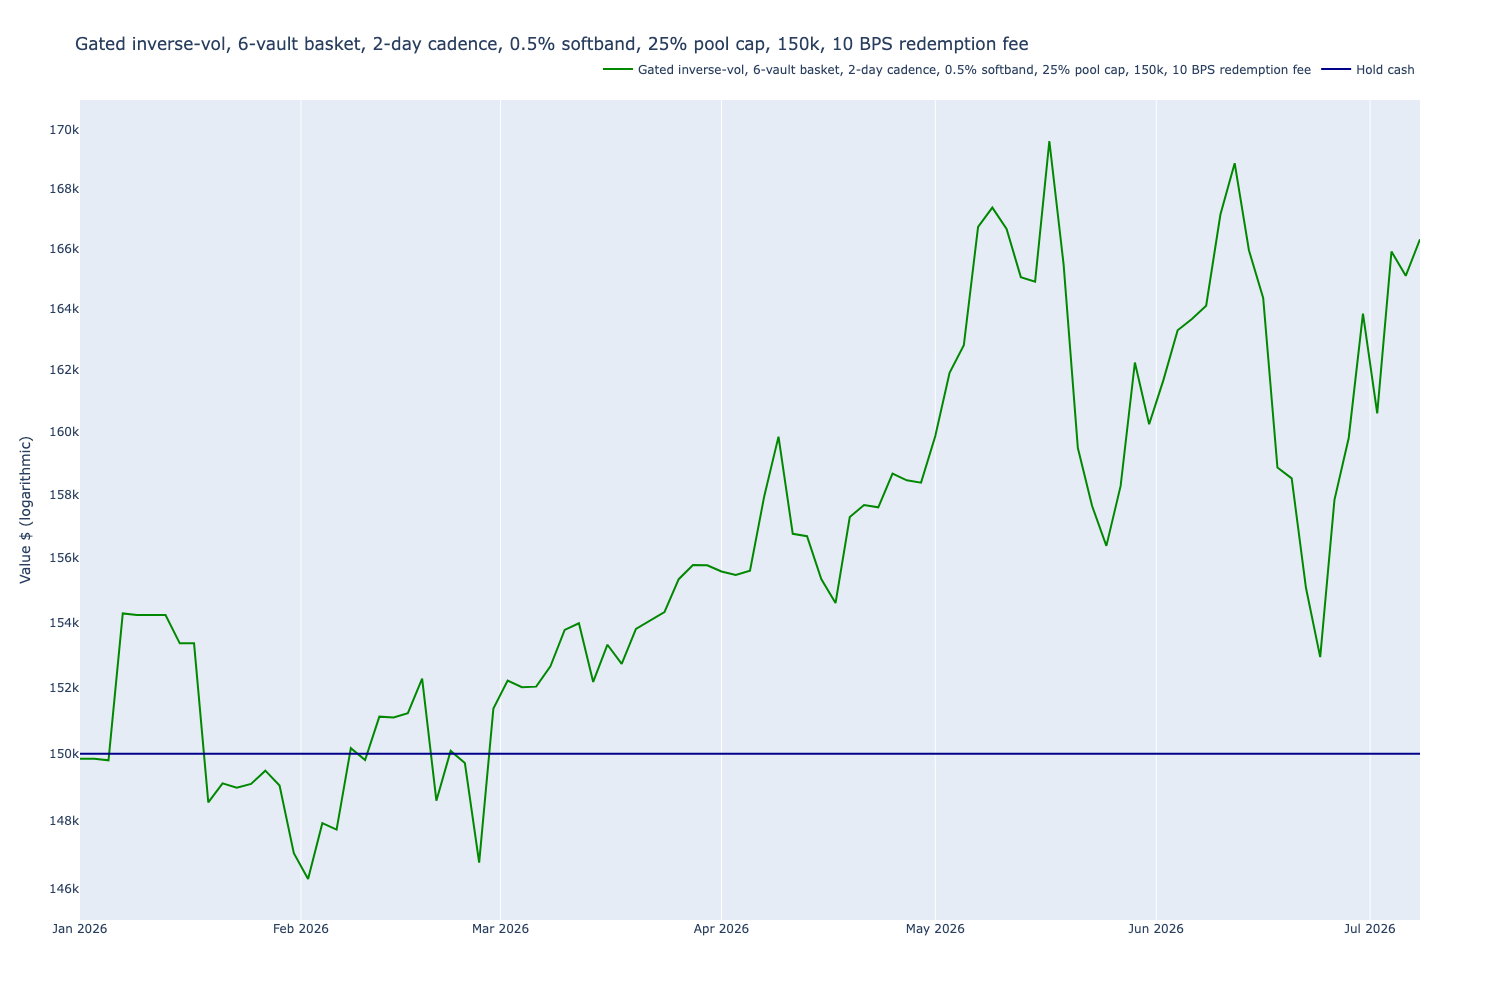

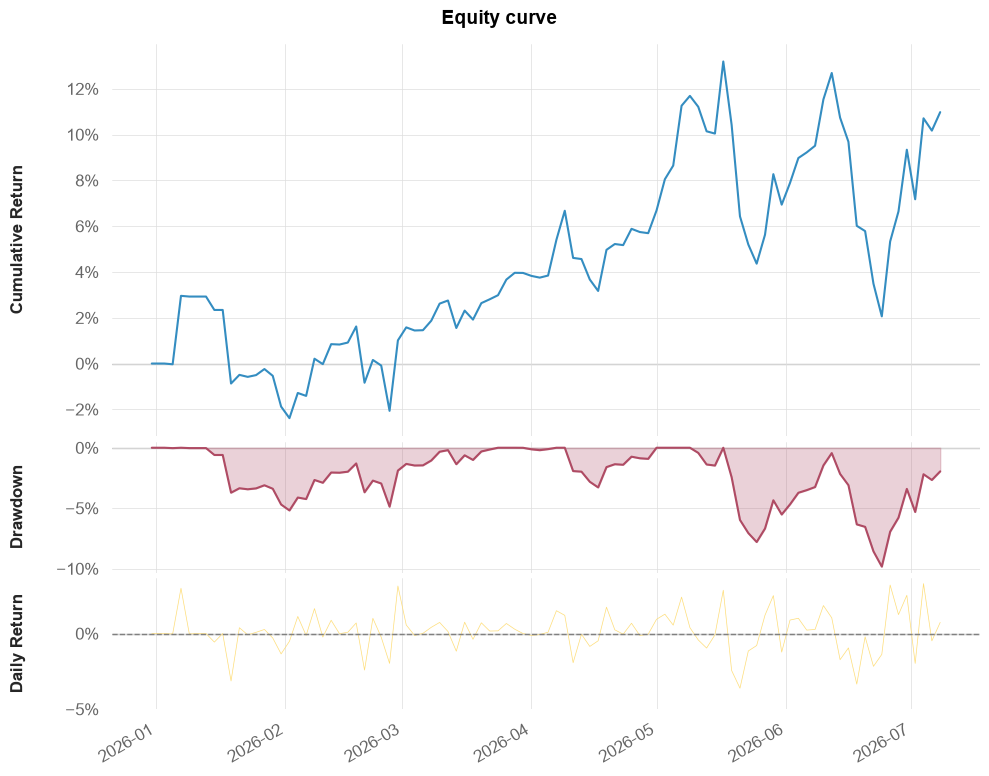

In [11]:
fig = chart_renderer.render(equity_curve_with_benchmark)
fig.show()

fig = chart_renderer.render(equity_curve_with_drawdown)
display(fig)


# Asset weights

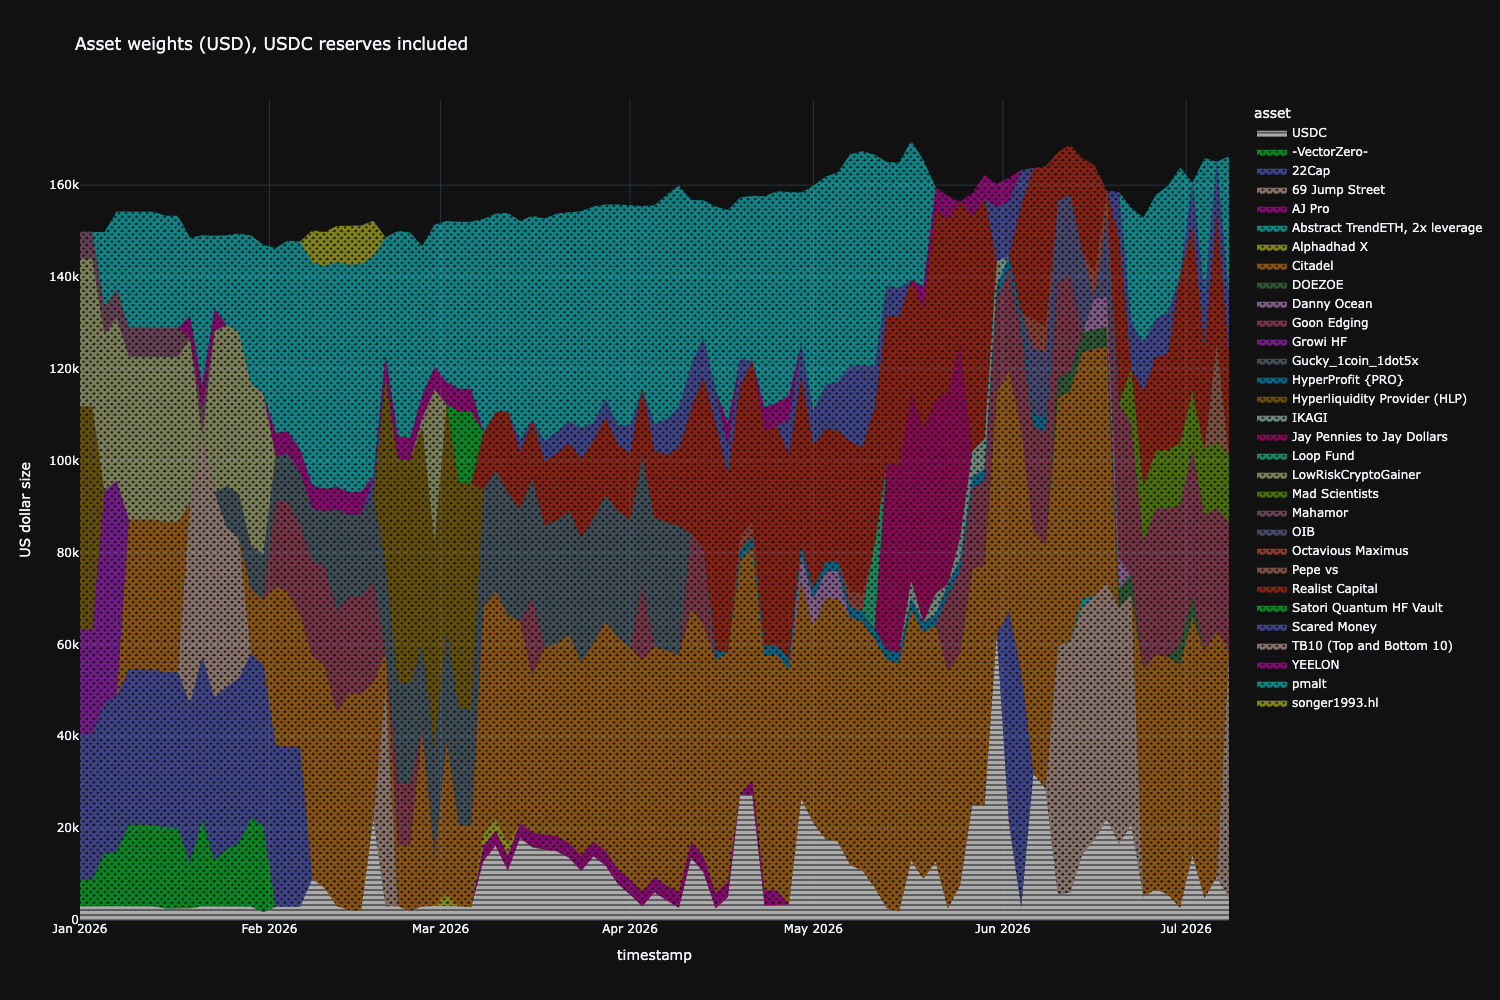

,At,Pair,Value,Address
Name,,,,
Max position (excluding USDC),2026-05-17,Citadel,"$54,855.06",
Min position (excluding USDC),2026-06-14,"Abstract TrendETH, 2x leverage","$1,919.55",
Mean position (excluding USDC),,,"$24,460.45",
Max position (excluding USDC),2026-05-31,Citadel,53.63%,
Min position (excluding USDC),2026-06-14,"Abstract TrendETH, 2x leverage",1.27%,
Mean position (excluding USDC),,,16.67%,
Max position (including USDC),2026-05-31,USDC,38.95%,
Min position (including USDC),2026-05-15,USDC,1.11%,
Mean position (including USDC),,,14.29%,


In [12]:
from tradeexecutor.utils.notebook import display_dataframe_with_html

fig = chart_renderer.render(equity_curve_by_asset)
display(fig)

display_dataframe_with_html(chart_renderer.render(weight_allocation_statistics))


# Monthly returns

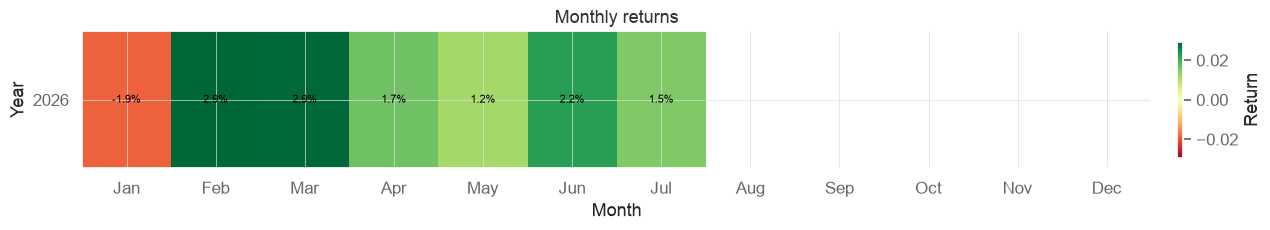

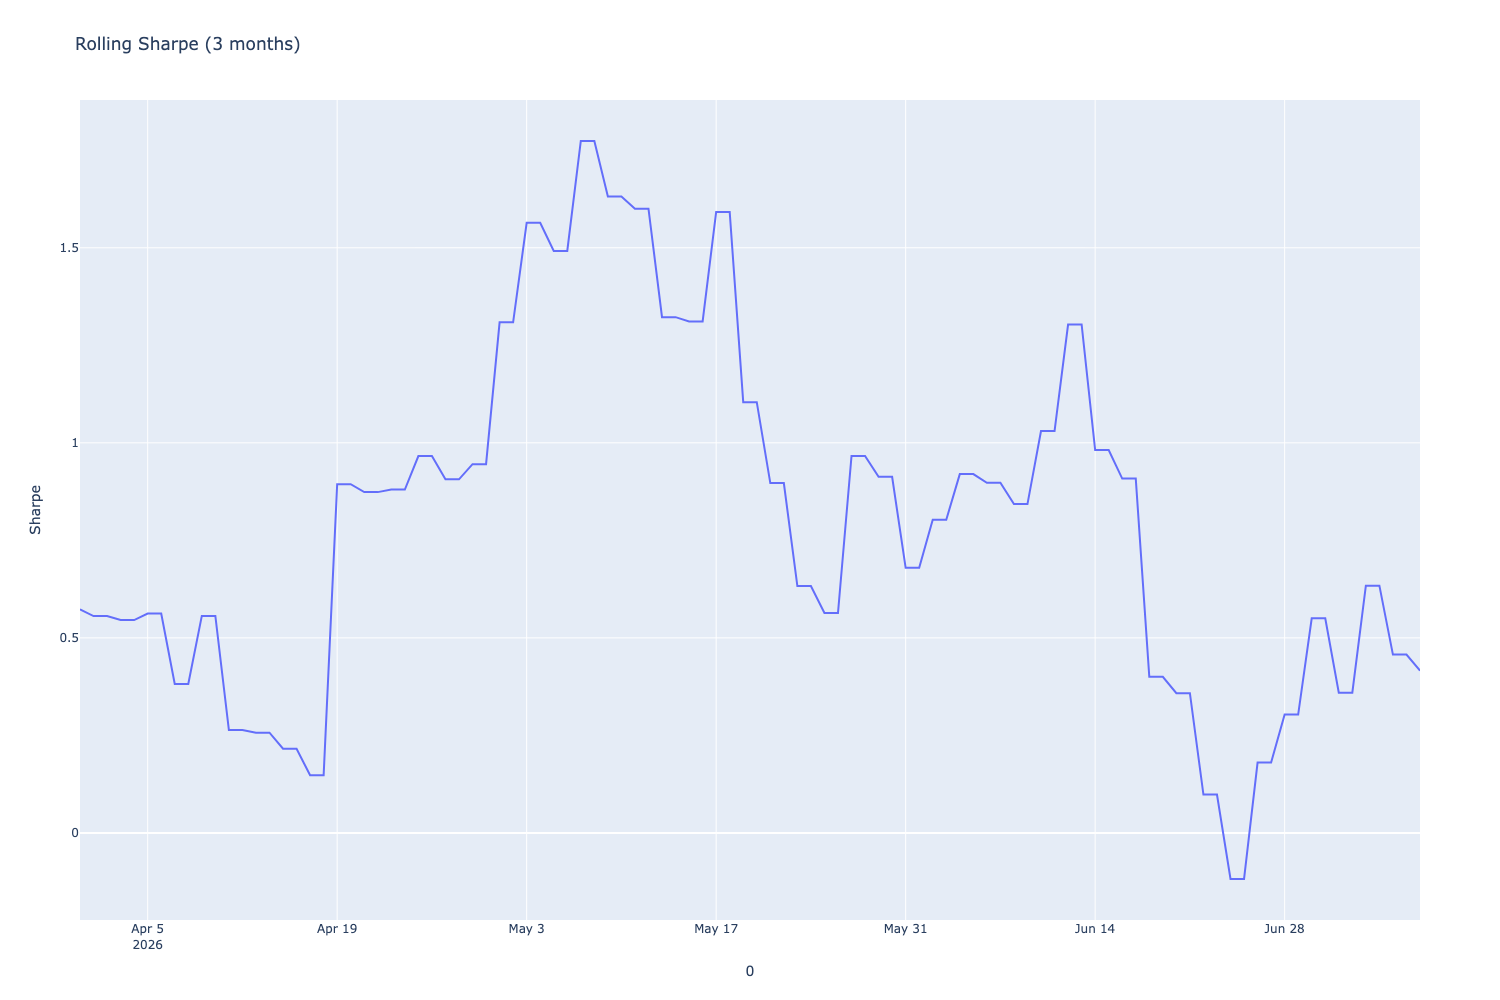

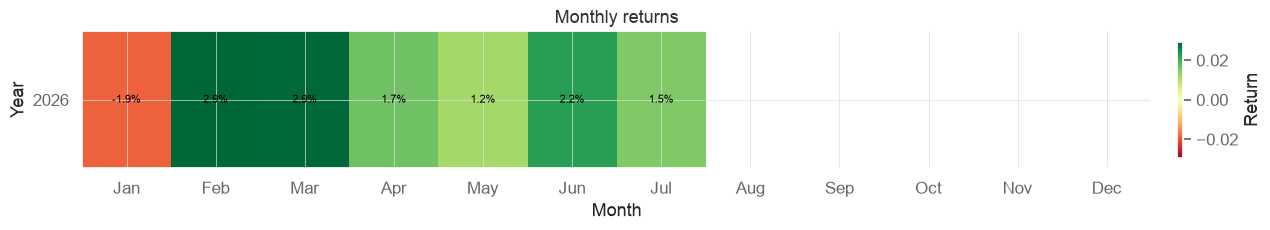

In [13]:
from tradeexecutor.visual.equity_curve import visualise_returns_over_time, calculate_rolling_sharpe
import plotly.express as px

display(visualise_returns_over_time(returns))

rolling_sharpe = calculate_rolling_sharpe(returns, freq="D", periods=90)
fig = px.line(rolling_sharpe, title="Rolling Sharpe (3 months)")
fig.update_layout(showlegend=False); fig.update_yaxes(title="Sharpe")
fig.show()


# Benchmark comparison and positions

In [14]:
from tradeexecutor.analysis.multi_asset_benchmark import compare_strategy_backtest_to_multiple_assets

display(compare_strategy_backtest_to_multiple_assets(state, strategy_universe, display=False, asset_count=2))

profit_by_position = sorted(
    ((p.get_realised_profit_usd() or 0.0, p) for p in positions),
    key=lambda x: x[0], reverse=True,
)
def pos_rows(items):
    return pd.DataFrame([{ 'Profit USD': pnl, 'Pair': p.pair.base.token_symbol,
        'Opened': p.opened_at, 'Closed': p.closed_at, 'Trades': len(p.trades) } for pnl, p in items])
print("Top 10 positions by profit:")
display(pos_rows(profit_by_position[:10]))
print("Biggest 8 losers:")
display(pos_rows(sorted(profit_by_position, key=lambda x: x[0])[:8]))

display(chart_renderer.render(positions_at_end))


,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-07-08,2026-07-08,2026-07-08
Risk-Free Rate,0,0,0
Time in Market,0.49,0.98,0.98
Cumulative Return,0.11,-0.32,-0.45
CAGR﹪,0.22,-0.52,-0.68
Sharpe,1.19,-1.28,-1.43
Prob. Sharpe Ratio,0.8,0.18,0.15
Smart Sharpe,1.18,-1.27,-1.42
Sortino,1.77,-1.72,-1.93


Top 10 positions by profit:


,Profit USD,Pair,Opened,Closed,Trades
0,5385.877199,Realist Ca,2026-06-24,NaT,8
1,5103.851885,pmalt,2026-01-05,2026-05-21,51
2,4463.043807,Realist Ca,2026-03-08,2026-05-31,33
3,4184.641194,Scared Mon,2026-04-27,2026-05-17,9
4,3608.746138,Goon Edgin,2026-05-23,2026-06-14,8
5,3056.407382,Goon Edgin,2026-02-02,2026-02-20,8
6,2804.053249,Growi HF,2026-01-01,2026-01-09,4
7,1224.185973,Citadel,2026-01-29,2026-06-20,53
8,839.053985,Gucky_1coi,2026-01-25,2026-04-11,21
9,532.207569,HyperProfi,2026-04-19,2026-06-10,3


Biggest 8 losers:


,Profit USD,Pair,Opened,Closed,Trades
0,-5094.262116,Citadel,2026-01-09,2026-01-19,3
1,-3880.488484,songer1993,2026-02-08,2026-02-20,4
2,-3406.193008,Pepe vs,2026-07-06,2026-07-08,2
3,-2425.282474,-VectorZer,2026-01-01,2026-02-02,12
4,-2248.143391,Realist Ca,2026-06-20,2026-06-22,2
5,-1646.477924,Goon Edgin,2026-02-22,2026-02-26,3
6,-1135.043218,Scared Mon,2026-05-31,2026-06-06,3
7,-1098.656427,IKAGI,2026-05-21,2026-05-23,2


,token,value,vault,protocol,link
position_id,,,,,
64,Goon Edgin,27983.694373,Goon Edging,hyperliquid,0x2431edfcb662e6ff6deab113cc91878a0b53fb0f
67,Mad Scient,14668.552234,Mad Scientists,hyperliquid,0x565b1c32936bdaa526947178acc95c5b08cfacc4
70,Realist Ca,22281.303282,Realist Capital,hyperliquid,0x77fee2df7bad4f1db93052fa82bf78eaab771a16
72,Scared Mon,12567.813419,Scared Money,hyperliquid,0x5290ab34acb59cfe1371baa5782eba14433d308f
75,69 Jump St,53756.512466,69 Jump Street,hyperliquid,0xa844d7ac9fa3424c4fd38a25baa23e460ec3e802
76,pmalt,30255.587666,pmalt,hyperliquid,0x4dec0a851849056e259128464ef28ce78afa27f6


# Cash deployment diagnostics

Why does the strategy hold cash? Per cycle, the allocator redistributes equity a capped
position cannot take to the *remaining selected* signals, but it hard-stops at
`max_assets_in_portfolio` positions — so once all selected vaults hit their caps
(`per_position_cap_of_pool_pct` x vault TVL, or `max_concentration_pct` x investable equity),
the remainder is stranded as cash. This section quantifies which cap binds and how much
cash it strands, parsed from the per-cycle diagnostics messages.


,value
cycles,95.00
mean cash %,7.10
median cash %,3.57
max cash %,100.00
final-cycle cash %,5.64
mean deployment shortfall % of investable,4.16
cycles with shortfall > 10% of investable,13.00
mean signals pool-capped per cycle,3.31
mean signals concentration-capped per cycle,1.94
cycles where ALL selected signals were pool-capped,0.00


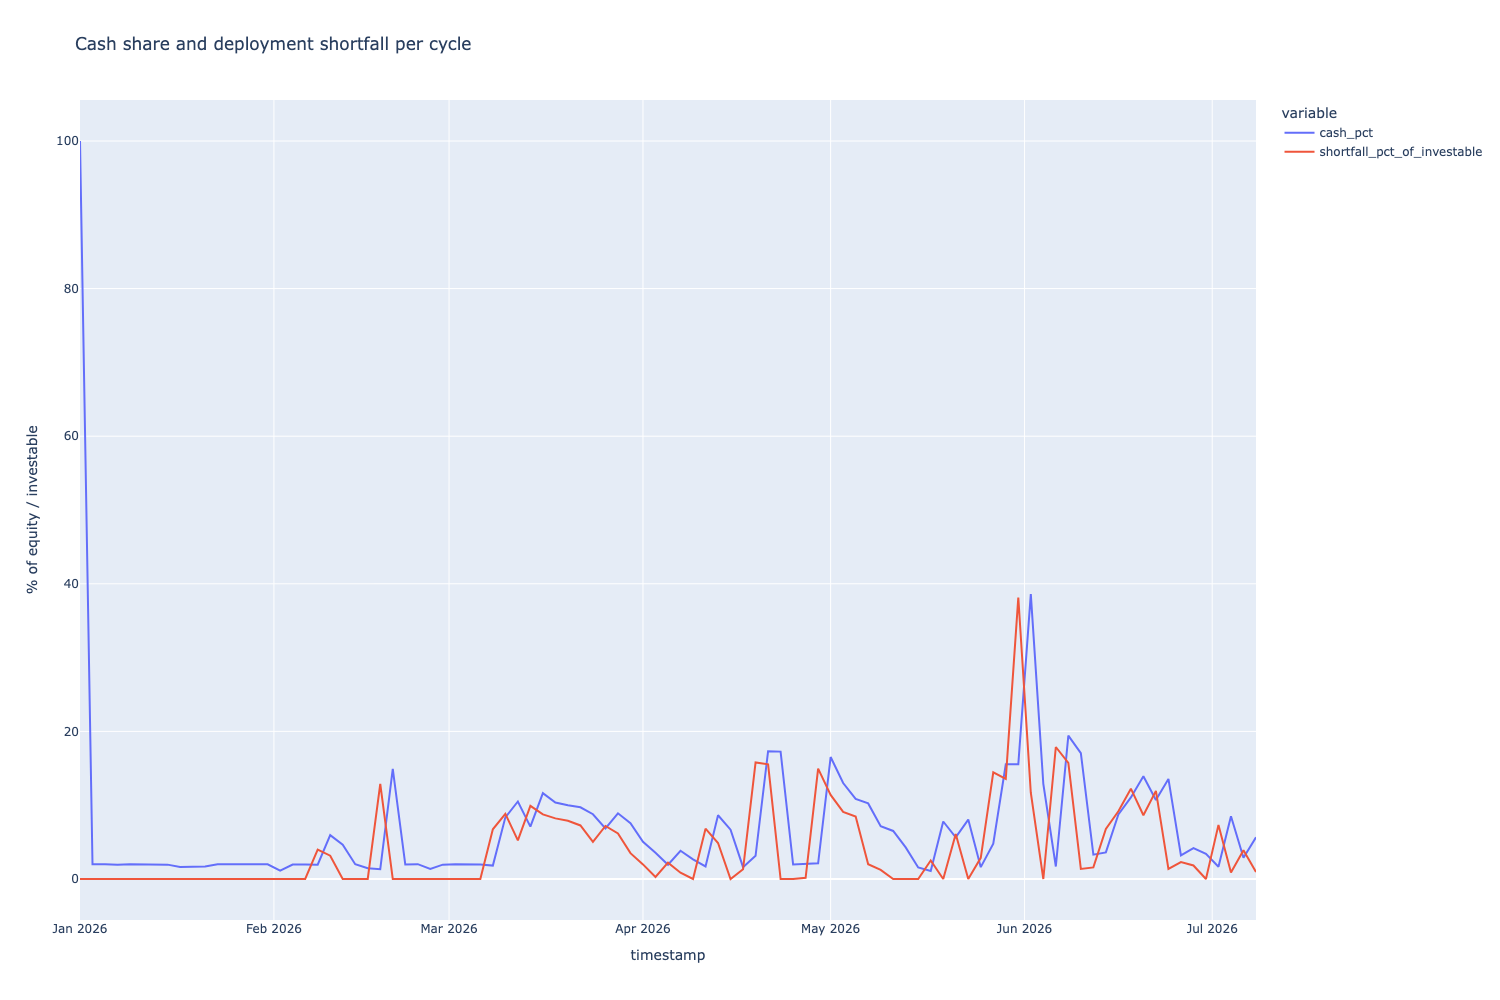

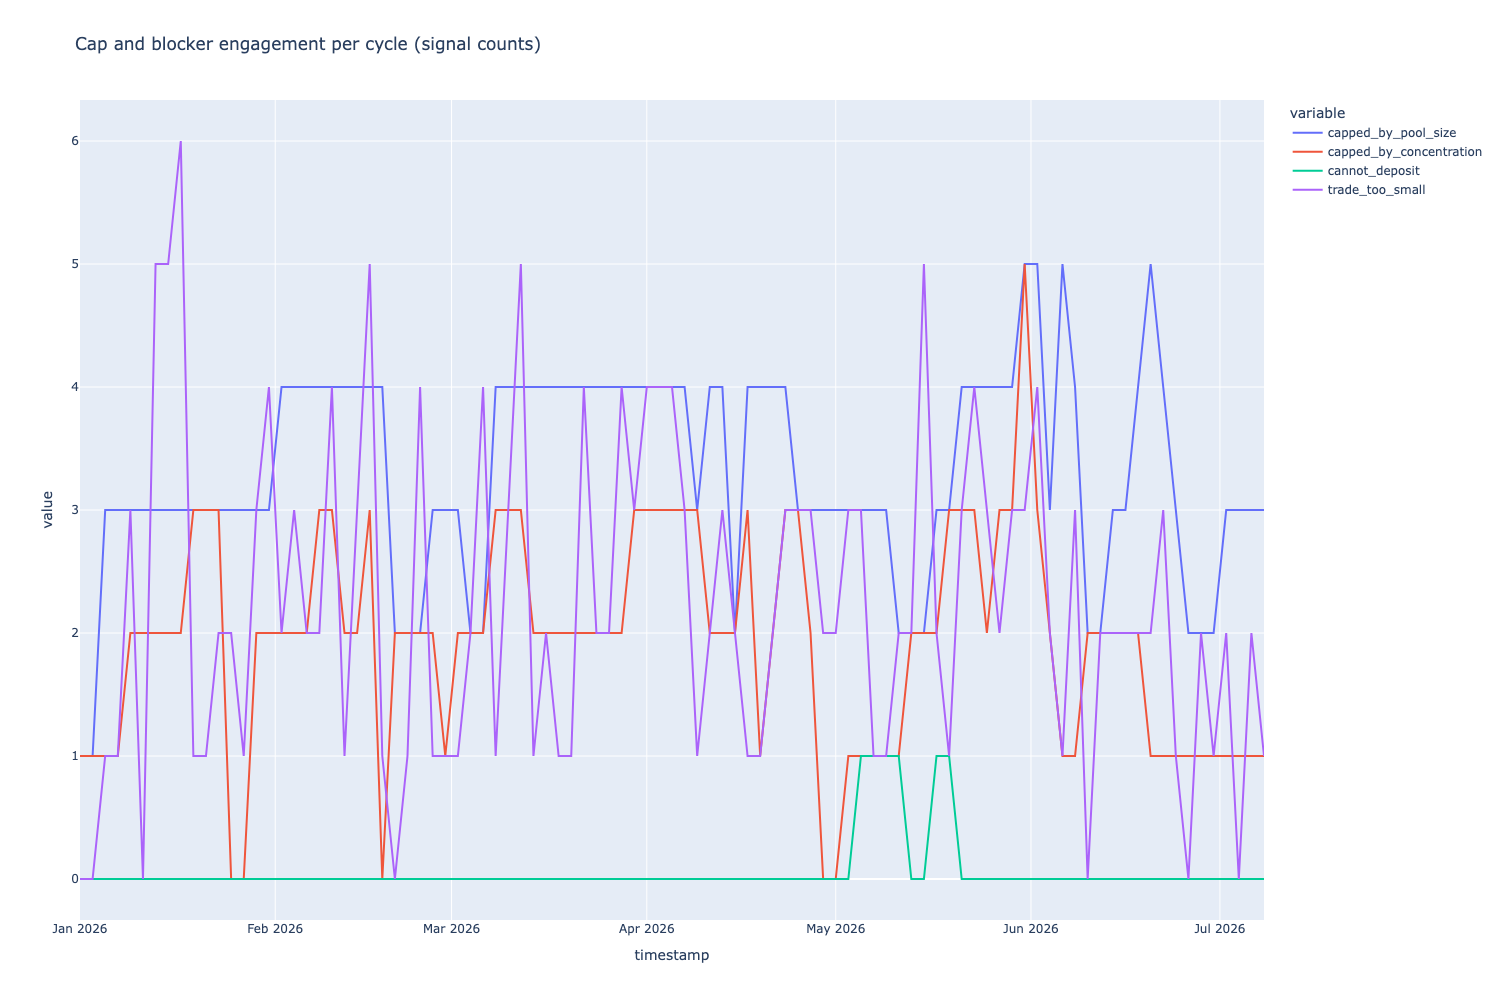

Last 30 cycles:


,cash_pct,cannot_deposit,deposit_window_skips,capped_by_pool_size,top_signal_pair
timestamp,,,,,
2026-05-11,6.5,1,1,2,Citadel-USDC
2026-05-13,4.3,0,1,2,Jay
2026-05-15,1.6,0,1,2,Jay
2026-05-17,1.1,1,2,3,Jay
2026-05-19,7.8,1,2,3,YEELON-USDC
2026-05-21,5.6,0,2,4,YEELON-USDC
2026-05-23,8.1,0,2,4,YEELON-USDC
2026-05-25,1.6,0,2,4,Jay
2026-05-27,4.8,0,2,4,YEELON-USDC


In [15]:
import re

import plotly.express as px


def extract_allocation_df(state) -> pd.DataFrame:
    """Parse per-cycle equity/cash/allocation and cap-flag counts from diagnostics messages."""
    rows = []
    for unix_ts, messages in sorted(state.visualisation.messages.items(), key=lambda item: item[0]):
        if not messages:
            continue
        message = '\n'.join(messages)

        def _usd(label):
            match = re.search(rf'{re.escape(label)}: ([0-9,.\-]+) USD', message)
            return float(match.group(1).replace(',', '')) if match else float('nan')

        def _count(label):
            match = re.search(rf'{re.escape(label)}: ([0-9]+)', message)
            return int(match.group(1)) if match else 0

        rows.append({
            'timestamp': datetime.datetime.fromtimestamp(unix_ts, datetime.timezone.utc).replace(tzinfo=None),
            'total_equity': _usd('Total equity'),
            'cash': _usd('Cash'),
            'investable': _usd('Investable equity'),
            'accepted': _usd('Accepted investable equity'),
            'discarded_liquidity': _usd('Discarded allocation because of lack of lit liquidity'),
            'candidates': _count('Candidate signals created'),
            'selected': _count('Selected survivor signals'),
            'capped_by_pool_size': _count('Signals with flag capped_by_pool_size'),
            'capped_by_concentration': _count('Signals with flag capped_by_concentration'),
            'cannot_deposit': _count('Signals with flag cannot_deposit'),
            'deposit_window_skips': _count('Candidates skipped for closed deposit window'),
            'trade_too_small': _count('Signals with flag individual_trade_size_too_small'),
            'top_signal_pair': (re.search(r'Top signal pair: (\S+)', message).group(1)
                                if re.search(r'Top signal pair: (\S+)', message) else None),
        })
    return pd.DataFrame(rows).set_index('timestamp')


alloc_df = extract_allocation_df(state)
alloc_df['cash_pct'] = alloc_df['cash'] / alloc_df['total_equity'] * 100
alloc_df['deployment_shortfall'] = alloc_df['investable'] - alloc_df['accepted']
alloc_df['shortfall_pct_of_investable'] = alloc_df['deployment_shortfall'] / alloc_df['investable'] * 100

deployment_summary = pd.Series({
    'cycles': len(alloc_df),
    'mean cash %': alloc_df['cash_pct'].mean(),
    'median cash %': alloc_df['cash_pct'].median(),
    'max cash %': alloc_df['cash_pct'].max(),
    'final-cycle cash %': alloc_df['cash_pct'].iloc[-1],
    'mean deployment shortfall % of investable': alloc_df['shortfall_pct_of_investable'].mean(),
    'cycles with shortfall > 10% of investable': int((alloc_df['shortfall_pct_of_investable'] > 10).sum()),
    'mean signals pool-capped per cycle': alloc_df['capped_by_pool_size'].mean(),
    'mean signals concentration-capped per cycle': alloc_df['capped_by_concentration'].mean(),
    'cycles where ALL selected signals were pool-capped': int(
        ((alloc_df['capped_by_pool_size'] >= alloc_df['selected']) & (alloc_df['selected'] > 0)).sum()
    ),
    'cycles with < 5 gated candidates': int((alloc_df['candidates'] < int(Parameters.max_assets_in_portfolio)).sum()),
    'cycles with a cannot_deposit signal (closed deposit window)': int((alloc_df['cannot_deposit'] > 0).sum()),
    'cycles skipping closed-window candidates at selection': int((alloc_df['deposit_window_skips'] > 0).sum()),
    'total closed-window candidates skipped at selection': int(alloc_df['deposit_window_skips'].sum()),
    'mean cash % when cannot_deposit engaged': alloc_df.loc[alloc_df['cannot_deposit'] > 0, 'cash_pct'].mean(),
    'mean cash % when no cannot_deposit': alloc_df.loc[alloc_df['cannot_deposit'] == 0, 'cash_pct'].mean(),
}, name='value')
display(deployment_summary.to_frame().round(2))

fig = px.line(alloc_df[['cash_pct', 'shortfall_pct_of_investable']], title='Cash share and deployment shortfall per cycle')
fig.update_yaxes(title='% of equity / investable')
fig.show()

fig = px.line(alloc_df[['capped_by_pool_size', 'capped_by_concentration', 'cannot_deposit', 'trade_too_small']], title='Cap and blocker engagement per cycle (signal counts)')
fig.show()

print('Last 30 cycles:')
display(alloc_df[['cash_pct', 'cannot_deposit', 'deposit_window_skips', 'capped_by_pool_size', 'top_signal_pair']].tail(30).round(1))


## End-of-backtest drill-down

The held vaults at the end, their TVL, and the pool cap each one imposes. If the sum of
pool caps is below investable equity, the cash pile is structural: the five selected
vaults simply cannot absorb the bankroll at a 15% TVL share.


In [16]:
final_rows = []
for position in state.portfolio.open_positions.values():
    pair = position.pair
    try:
        tvl_series = indicator_data.get_indicator_series('tvl', pair=pair)
        last_tvl = float(tvl_series.dropna().iloc[-1])
    except Exception:
        last_tvl = float('nan')
    final_rows.append({
        'Vault': pair.base.token_symbol,
        'Position value USD': float(position.get_value()),
        'Vault TVL USD': last_tvl,
        'Pool cap (15% of TVL) USD': last_tvl * float(Parameters.per_position_cap_of_pool_pct),
    })
final_positions_df = pd.DataFrame(final_rows).sort_values('Position value USD', ascending=False)
display(final_positions_df.round(0))

final_cycle = alloc_df.iloc[-1]
print(f"Final cycle equity: {final_cycle['total_equity']:,.0f} USD, cash: {final_cycle['cash']:,.0f} USD ({final_cycle['cash_pct']:.1f}%)")
print(f"Investable (98% target): {final_cycle['investable']:,.0f} USD, accepted by caps: {final_cycle['accepted']:,.0f} USD")
print(f"Sum of pool caps across held vaults: {final_positions_df['Pool cap (15% of TVL) USD'].sum():,.0f} USD")

print()
print('Last cycle raw diagnostics:')
last_ts = max(state.visualisation.messages)
print('\n'.join(state.visualisation.messages[last_ts]))


,Vault,Position value USD,Vault TVL USD,Pool cap (15% of TVL) USD
4,69 Jump St,53757.0,258067.0,64517.0
5,pmalt,30256.0,513987.0,128497.0
0,Goon Edgin,27984.0,108169.0,27042.0
2,Realist Ca,22281.0,485292.0,121323.0
1,Mad Scient,14669.0,59388.0,14847.0
3,Scared Mon,12568.0,50278.0,12569.0


Final cycle equity: 166,389 USD, cash: 9,388 USD (5.6%)
Investable (98% target): 163,062 USD, accepted by caps: 161,499 USD
Sum of pool caps across held vaults: 368,795 USD

Last cycle raw diagnostics:
Cycle: #95
Rebalanced: 👍
Open/about to open positions: 8
Max position value change: 53,810.32 USD
Rebalance threshold: 75.00 USD
Trades decided: 7
Pairs meeting inclusion criteria: 199
Pairs meeting TVL inclusion criteria: 202
Candidate signals created: 186
Selected survivor signals: 8
Candidates skipped for closed deposit window: 1
CAGR lookback days: 360
Sharpe lookback days: 180
CAGR weight (blend): 0.5
Total equity: 166,389.37 USD
Cash: 9,387.65 USD
Redeemable capital: 157,001.72 USD
Pending redemptions: 0.00 USD
Investable equity: 163,061.58 USD
Accepted investable equity: 161,498.72 USD
Allocated to signals: 161,498.72 USD
Discarded allocation because of lack of lit liquidity: 23,498.07 USD
Rebalance volume: 0.00 USD
Top signal pair: 69 Jump St-USDC
Top signal value: 250.8612139825

# Redemption fee verification and cost accounting

Verify the fee actually reached the executed sell prices, and total up what it cost.

Two sell paths exist and both must be checked:

- **Full closes** go through `PositionManager.close_position()`, which prices straight off
  `BacktestPricing.get_sell_price()`, so the fee lands as `share price x (1 - fee)`.
- **Partial reductions** of a Hypercore position go through `PositionManager.adjust_position()`,
  which overrides the pricing-model price with the position's *marked* price
  (trade-executor `7e673dc6`, so live partial redemptions size off the live implied share price).
  That marked price is itself produced by `BacktestValuationModel` from `get_sell_price()` at the
  same cycle timestamp, so the fee is still charged — but the trade's `planned_mid_price` is
  overwritten with the same value and can no longer be used to measure it.

The verification below is therefore independent of both paths: it compares each executed sell
price against the vault's own daily close (share price) at the time the trade was planned.


,Trades,Configured fee,Median implied fee,Mean implied fee,Within 1 BPS of configured
Sell type,,,,,
Full close,70,0.100%,0.100%,-1.439%,54.3%
Partial reduction,92,0.100%,0.100%,-1.035%,51.1%
All sells,162,0.100%,0.100%,-1.210%,52.5%


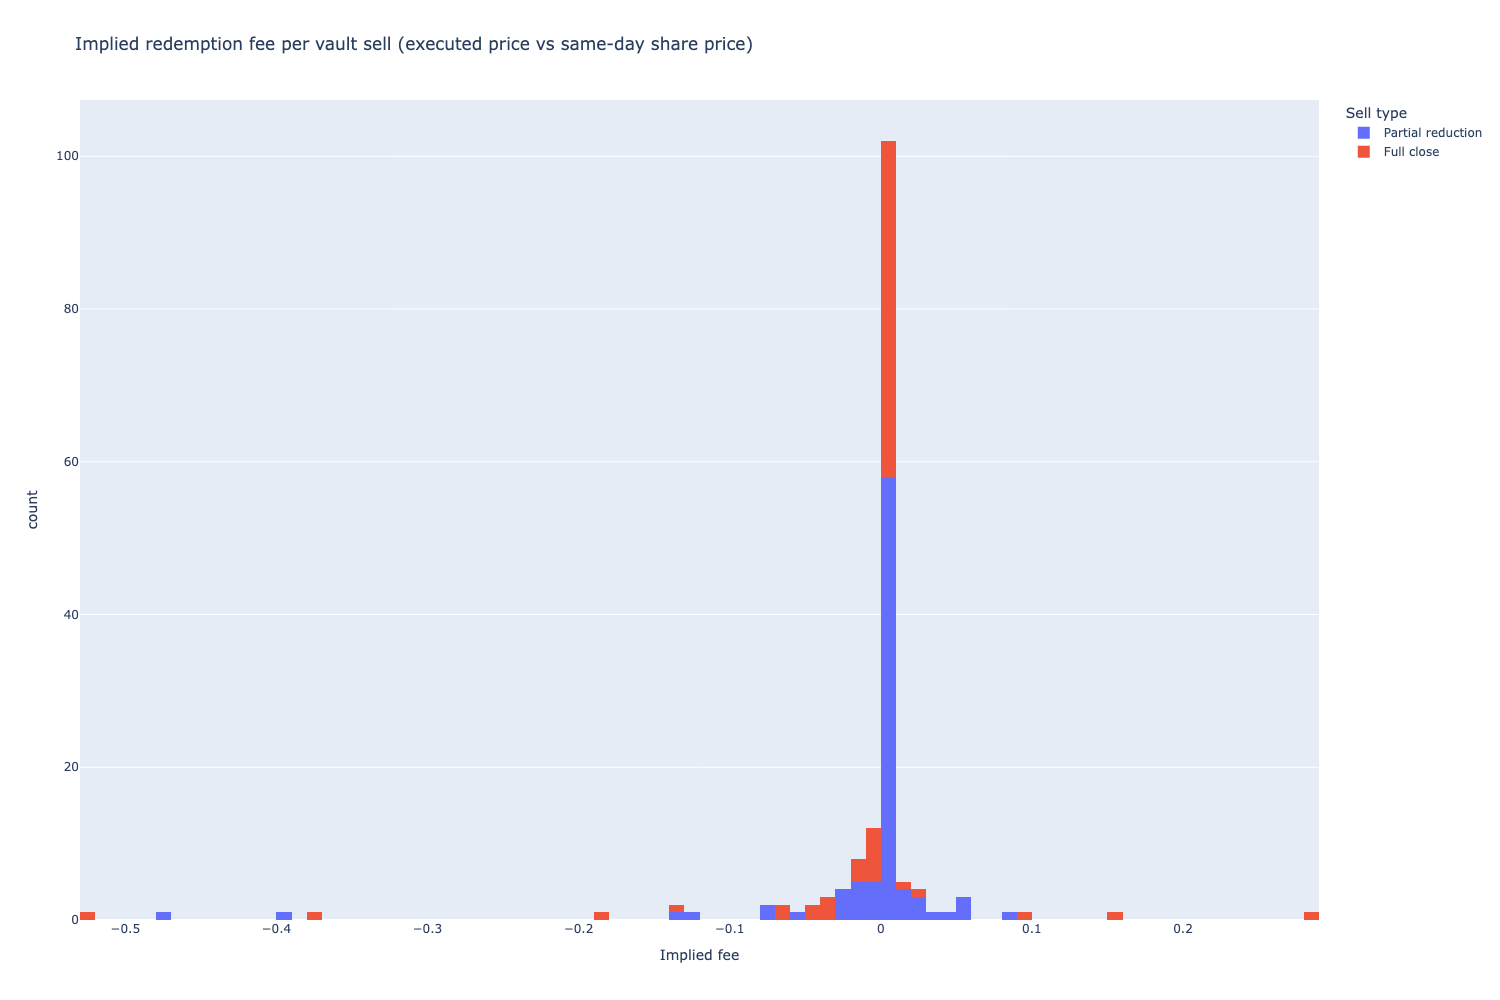

,Vault sell trades,Redemption volume USD,Redemption fee paid USD,Fee as % of initial capital,Fee as % of final equity,Redemption turnover x initial capital
0,162,"$1,729,407","$1,731",1.15%,1.04%,11.5x


,Sells,Proceeds USD,Fee paid USD
Vault,,,
Citadel,23,"$265,652",$265.92
pmalt,27,"$237,567",$237.80
Realist Ca,21,"$231,611",$231.84
69 Jump St,10,"$151,845",$152.00
Goon Edgin,16,"$122,429",$122.55
LowRiskCry,3,"$103,591",$103.69
Hyperliqui,4,"$101,455",$101.56
22Cap,2,"$86,257",$86.34
Scared Mon,12,"$58,912",$58.97


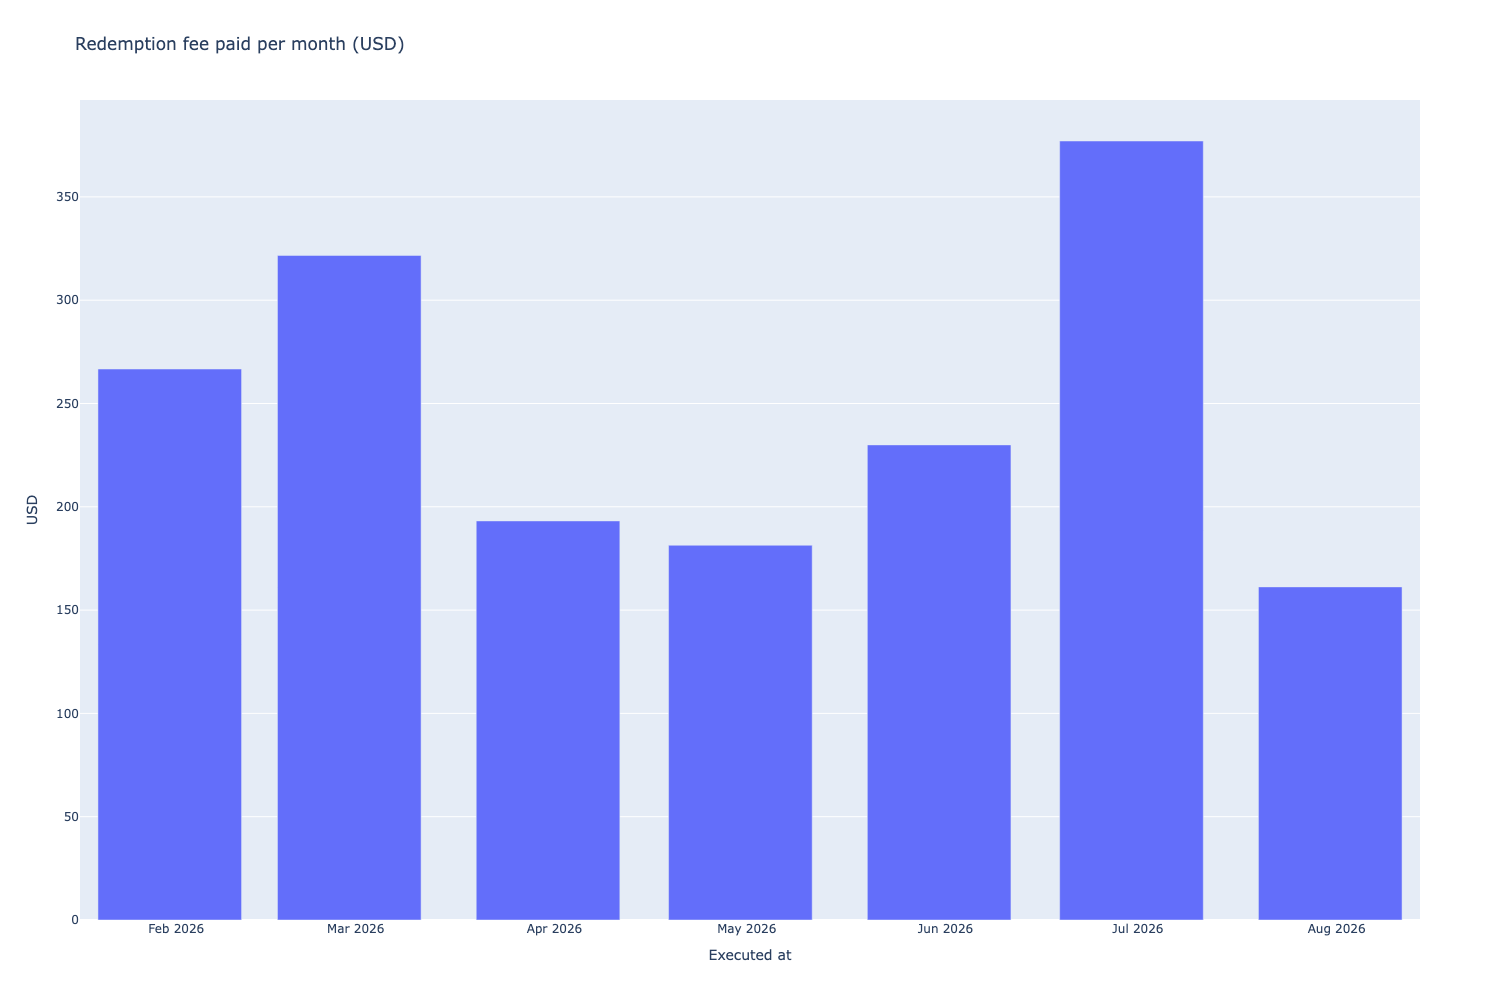

In [17]:
vault_close_cache = {}


def get_vault_share_price(pair, ts) -> float:
    """Vault share price (daily close) as of ``ts``, straight from the candle data."""
    closes = vault_close_cache.get(pair.internal_id)
    if closes is None:
        candles = strategy_universe.data_universe.candles.get_candles_by_pair(pair.internal_id)
        closes = candles.set_index('timestamp')['close'].sort_index()
        vault_close_cache[pair.internal_id] = closes
    window = closes.loc[closes.index <= pd.Timestamp(ts)]
    return float(window.iloc[-1]) if len(window) else float('nan')


def build_vault_sell_df(state_, fee_: float) -> pd.DataFrame:
    """Every successful vault sell, with the fee implied by its executed price.

    :param fee_:
        Redemption fee configured for the run that produced ``state_``.
    """
    rows = []
    for trade in state_.portfolio.get_all_trades():
        if not trade.pair.is_vault():
            continue
        if not trade.is_sell() or not trade.is_success():
            continue
        share_price = get_vault_share_price(trade.pair, trade.opened_at)
        proceeds = abs(float(trade.executed_reserve or 0.0))
        rows.append({
            'Vault': trade.pair.base.token_symbol,
            'Planned at': trade.opened_at,
            'Executed at': trade.executed_at,
            'Sell type': 'Full close' if trade.closing else 'Partial reduction',
            'Share price': share_price,
            'Planned price': float(trade.planned_price),
            'Implied fee': float(1.0 - trade.planned_price / share_price) if share_price == share_price else float('nan'),
            'Proceeds USD': proceeds,
            'Fee paid USD': proceeds * fee_ / (1.0 - fee_) if fee_ else 0.0,
        })
    return pd.DataFrame(rows)


def summarise_implied_fees(df: pd.DataFrame, fee_: float) -> pd.DataFrame:
    """Implied-fee statistics, split by sell type."""
    rows = []
    for sell_type, group in list(df.groupby('Sell type')) + [('All sells', df)]:
        implied = group['Implied fee'].dropna()
        rows.append({
            'Sell type': sell_type,
            'Trades': len(group),
            'Configured fee': fee_,
            'Median implied fee': float(implied.median()),
            'Mean implied fee': float(implied.mean()),
            'Within 1 BPS of configured': float((implied.sub(fee_).abs() <= 0.0001).mean()),
        })
    return pd.DataFrame(rows).set_index('Sell type')


fee = Parameters.vault_redemption_fee
vault_sell_df = build_vault_sell_df(state, fee)

display(
    summarise_implied_fees(vault_sell_df, fee).style.format({
        'Configured fee': '{:.3%}',
        'Median implied fee': '{:.3%}',
        'Mean implied fee': '{:.3%}',
        'Within 1 BPS of configured': '{:.1%}',
    }).set_caption('Implied redemption fee by sell type')
)

fig = px.histogram(
    vault_sell_df,
    x='Implied fee',
    color='Sell type',
    nbins=120,
    title='Implied redemption fee per vault sell (executed price vs same-day share price)',
)
fig.show()

total_fee_usd = float(vault_sell_df['Fee paid USD'].sum())
total_proceeds_usd = float(vault_sell_df['Proceeds USD'].sum())
final_equity = float(equity.iloc[-1])

fee_summary_df = pd.DataFrame([{
    'Vault sell trades': len(vault_sell_df),
    'Redemption volume USD': total_proceeds_usd,
    'Redemption fee paid USD': total_fee_usd,
    'Fee as % of initial capital': total_fee_usd / Parameters.initial_cash,
    'Fee as % of final equity': total_fee_usd / final_equity,
    'Redemption turnover x initial capital': total_proceeds_usd / Parameters.initial_cash,
}])
display(fee_summary_df.style.format({
    'Redemption volume USD': '${:,.0f}',
    'Redemption fee paid USD': '${:,.0f}',
    'Fee as % of initial capital': '{:.2%}',
    'Fee as % of final equity': '{:.2%}',
    'Redemption turnover x initial capital': '{:.1f}x',
}))

fee_by_vault_df = vault_sell_df.groupby('Vault').agg(
    **{
        'Sells': ('Proceeds USD', 'size'),
        'Proceeds USD': ('Proceeds USD', 'sum'),
        'Fee paid USD': ('Fee paid USD', 'sum'),
    }
).sort_values('Fee paid USD', ascending=False)
display(
    fee_by_vault_df.head(15).style.format({
        'Proceeds USD': '${:,.0f}',
        'Fee paid USD': '${:,.2f}',
    }).set_caption('Redemption fee paid by vault (top 15)')
)

monthly_fee = vault_sell_df.set_index('Executed at')['Fee paid USD'].resample('1ME').sum()
fig = px.bar(monthly_fee, title='Redemption fee paid per month (USD)')
fig.update_layout(showlegend=False)
fig.update_yaxes(title='USD')
fig.show()


# A/B against the same run without the redemption fee

The honest way to price the fee is to re-run the identical strategy on the identical universe
with the fee switched off, rather than to compare against NB53's committed numbers (vault data
is refreshed between runs, so those numbers drift for reasons unrelated to the fee).

The only difference between the two runs below is the vault sell-side fee.


In [18]:
# Same universe, same indicators, same decide_trades - only the redemption fee differs.
apply_vault_redemption_fee(strategy_universe, 0.0)

baseline_result = run_backtest_inline(
    name="Gated inverse-vol, 6-vault basket, 2-day cadence, 0.5% softband, 25% pool cap, 150k, no redemption fee",
    engine_version="0.5",
    decide_trades=decide_trades,
    indicator_combinations=indicator_data.indicator_combinations,
    cycle_duration=Parameters.cycle_duration,
    client=client,
    universe=strategy_universe,
    parameters=parameters,
    max_workers=1,
    start_at=Parameters.backtest_start,
    end_at=Parameters.backtest_end,
)

# Restore the configured fee so the rest of the notebook sees the fee-charging universe.
apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)

baseline_state = baseline_result.state
baseline_equity = calculate_equity_curve(baseline_state)
baseline_returns = calculate_returns(baseline_equity)
baseline_positions = [p for p in baseline_state.portfolio.get_all_positions() if not p.is_credit_supply()]
print(f"Baseline (no fee) final equity: ${baseline_equity.iloc[-1]:,.0f}")
print(f"10 BPS fee       final equity: ${equity.iloc[-1]:,.0f}")


Baseline (no fee) final equity: $168,176
10 BPS fee       final equity: $166,304


,Final equity,Cumulative return,CAGR,Sharpe,Sortino,Max drawdown,Positions,Trades
"Baseline, no redemption fee","$168,176",12.12%,24.86%,1.30,1.95,-9.59%,76,406
10 BPS redemption fee,"$166,304",10.87%,22.41%,1.19,1.77,-9.83%,76,411
Difference,"$-1,872",-1.25%,-2.45%,-0.11,-0.18,-0.24%,0,5


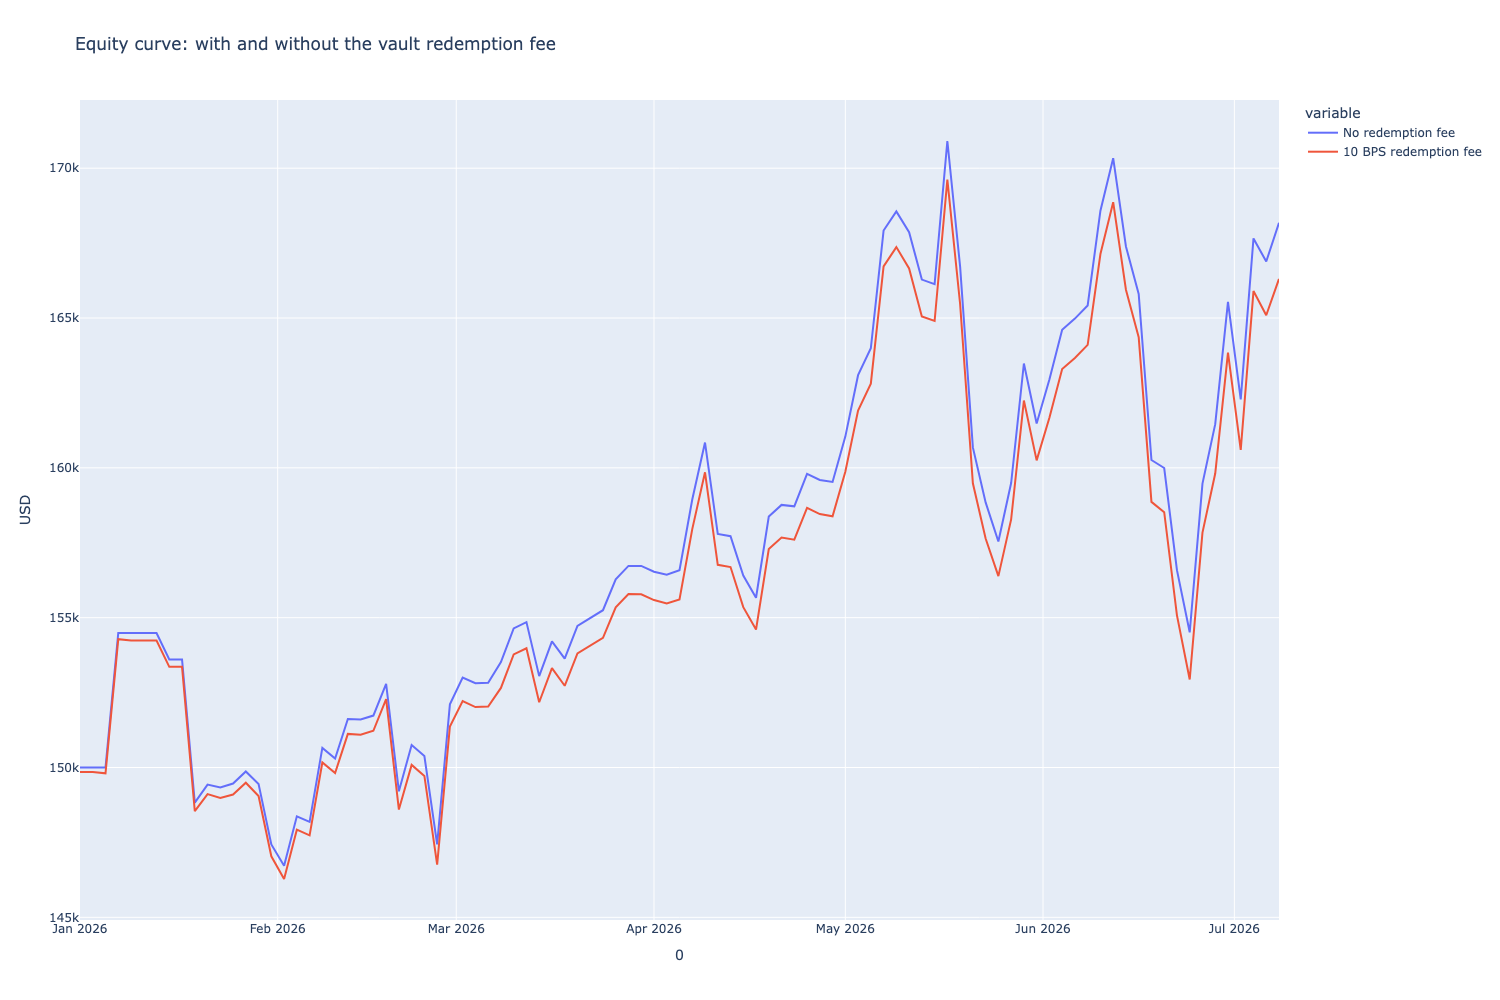

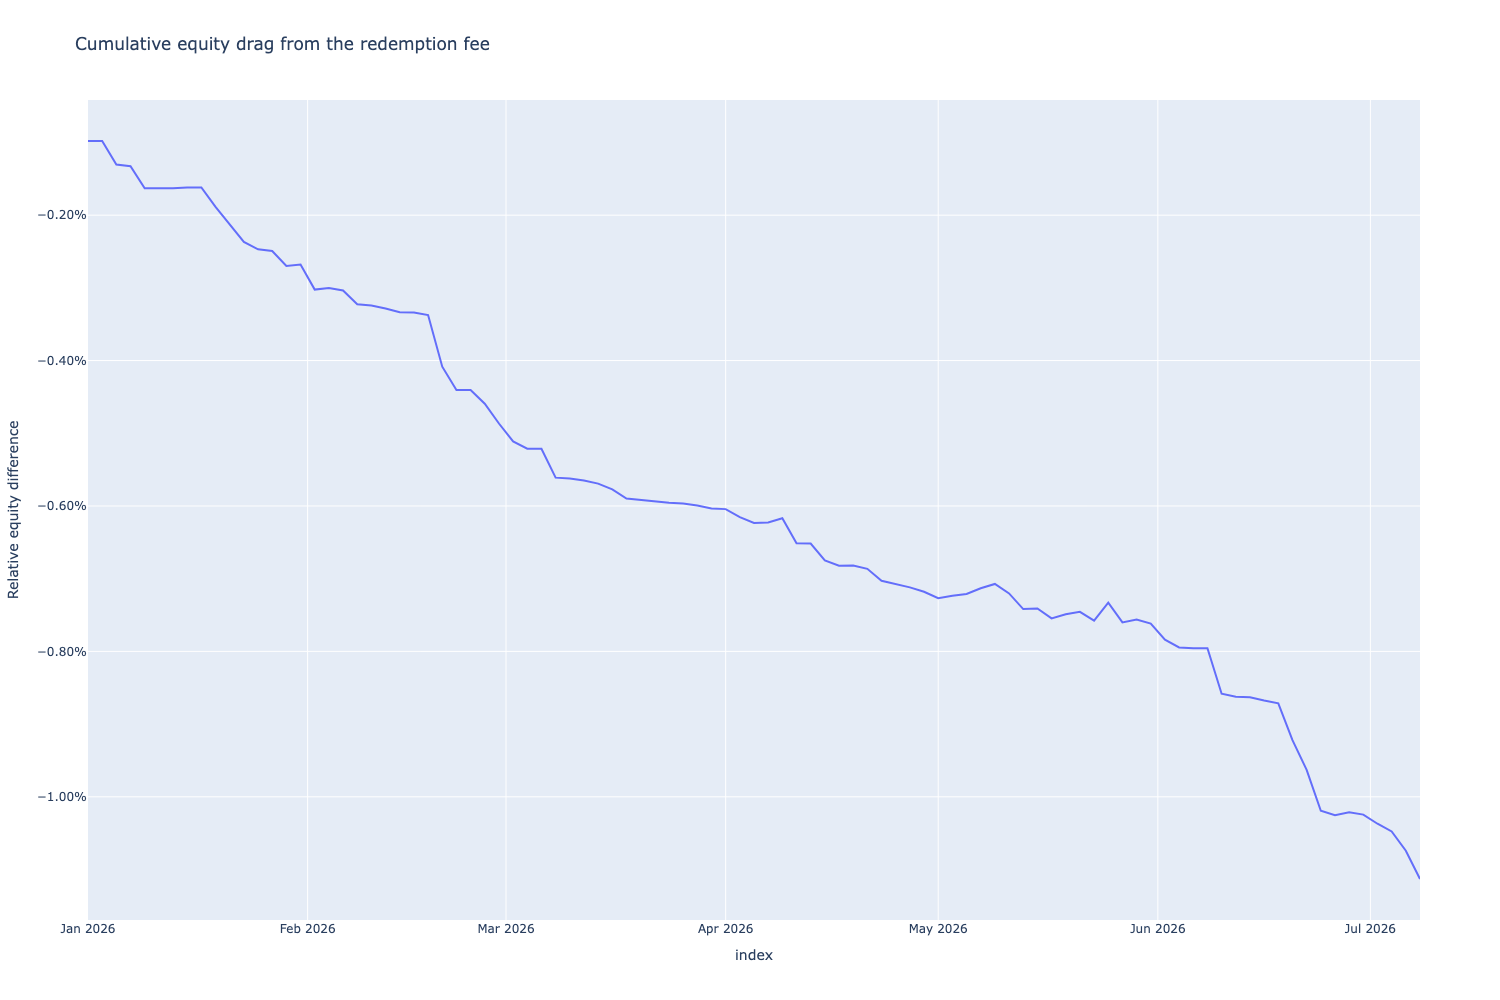

,Final equity difference USD,Final relative drag,Worst relative drag,Drag per year,Redemption fee paid USD (accounting)
0,"$-1,872",-1.11%,-1.11%,-2.16%,"$1,731"


In [19]:
from tradeexecutor.statistics.key_metric import (
    calculate_cagr,
    calculate_max_drawdown,
    calculate_sharpe,
    calculate_sortino,
)


def summarise_run(label: str, equity_curve: pd.Series, state_) -> dict:
    """Headline metrics for one backtest run.

    The equity curve is sampled **once per strategy cycle**, so a 2-day cadence produces one
    observation every 48 hours. Annualising that series with ``periods=365`` would overstate its
    Sharpe and Sortino by ``sqrt(2)`` against a daily-cadence run and make the two incomparable.
    Resample onto a common daily grid first - a 2-day step becomes one non-zero day and one zero
    day, which annualises correctly and matches the basis used in the robustness cell.

    Max drawdown is still measured on whatever grid the strategy values itself: a 2-day cadence
    cannot observe a trough that opens and closes inside one of its cycles, so its drawdown is
    measured over fewer marks than a daily cadence. That is a property of the schedule, not of
    this function.
    """
    return_series = calculate_returns(equity_curve).resample("1D").sum(min_count=1).fillna(0.0).dropna()
    trades = list(state_.portfolio.get_all_trades())
    run_positions = [p for p in state_.portfolio.get_all_positions() if not p.is_credit_supply()]
    return {
        'Run': label,
        'Final equity': float(equity_curve.iloc[-1]),
        'Cumulative return': float(equity_curve.iloc[-1] / Parameters.initial_cash - 1.0),
        'CAGR': float(calculate_cagr(return_series)),
        'Sharpe': float(calculate_sharpe(return_series, periods=365)),
        'Sortino': float(calculate_sortino(return_series, periods=365)),
        'Max drawdown': float(calculate_max_drawdown(return_series)),
        'Positions': len(run_positions),
        'Trades': len(trades),
    }


comparison_df = pd.DataFrame([
    summarise_run('Baseline, no redemption fee', baseline_equity, baseline_state),
    summarise_run(f'{Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee', equity, state),
]).set_index('Run')
delta = comparison_df.iloc[1] - comparison_df.iloc[0]
delta.name = 'Difference'
comparison_df = pd.concat([comparison_df, delta.to_frame().T])
display(comparison_df.style.format({
    'Final equity': '${:,.0f}',
    'Cumulative return': '{:.2%}',
    'CAGR': '{:.2%}',
    'Sharpe': '{:.2f}',
    'Sortino': '{:.2f}',
    'Max drawdown': '{:.2%}',
    'Positions': '{:.0f}',
    'Trades': '{:.0f}',
}))

equity_comparison_df = pd.DataFrame({
    'No redemption fee': baseline_equity,
    f'{Parameters.vault_redemption_fee * 10_000:.0f} BPS redemption fee': equity,
}).ffill()
fig = px.line(equity_comparison_df, title='Equity curve: with and without the vault redemption fee')
fig.update_yaxes(title='USD')
fig.show()

drag = (equity_comparison_df.iloc[:, 1] / equity_comparison_df.iloc[:, 0] - 1.0)
fig = px.line(drag, title='Cumulative equity drag from the redemption fee')
fig.update_layout(showlegend=False)
fig.update_yaxes(title='Relative equity difference', tickformat='.2%')
fig.show()

drag_df = pd.DataFrame([{
    'Final equity difference USD': float(equity.iloc[-1] - baseline_equity.iloc[-1]),
    'Final relative drag': float(drag.iloc[-1]),
    'Worst relative drag': float(drag.min()),
    'Drag per year': float(drag.iloc[-1]) / ((equity.index[-1] - equity.index[0]).days / 365.0),
    'Redemption fee paid USD (accounting)': total_fee_usd,
}])
display(drag_df.style.format({
    'Final equity difference USD': '${:,.0f}',
    'Final relative drag': '{:.2%}',
    'Worst relative drag': '{:.2%}',
    'Drag per year': '{:.2%}',
    'Redemption fee paid USD (accounting)': '${:,.0f}',
}))


In [20]:
# Control: the same implied-fee measurement on the no-fee baseline run.
#
# Hypercore partial reductions execute at the position's marked price, which is a cycle-start
# valuation and can differ from the same-day close for reasons that have nothing to do with the
# fee (stale marks, positions opened the same cycle, async settlement). The baseline run isolates
# that measurement noise: its implied fees must centre on zero, and the fee run must be the same
# distribution shifted by exactly the configured fee.
baseline_sell_df = build_vault_sell_df(baseline_state, 0.0)

control_df = pd.concat([
    summarise_implied_fees(baseline_sell_df, 0.0).assign(Run='Baseline, no fee'),
    summarise_implied_fees(vault_sell_df, Parameters.vault_redemption_fee).assign(Run='10 BPS fee'),
]).set_index('Run', append=True).reorder_levels(['Run', 'Sell type'])
display(control_df.style.format({
    'Configured fee': '{:.3%}',
    'Median implied fee': '{:.3%}',
    'Mean implied fee': '{:.3%}',
    'Within 1 BPS of configured': '{:.1%}',
}).set_caption('Implied fee measurement, fee run vs no-fee control'))

shift_df = pd.DataFrame([{
    'Median implied fee, baseline': float(baseline_sell_df['Implied fee'].median()),
    'Median implied fee, fee run': float(vault_sell_df['Implied fee'].median()),
    'Median shift': float(vault_sell_df['Implied fee'].median() - baseline_sell_df['Implied fee'].median()),
    'Mean shift': float(vault_sell_df['Implied fee'].mean() - baseline_sell_df['Implied fee'].mean()),
    'Configured fee': Parameters.vault_redemption_fee,
}])
display(shift_df.style.format('{:.3%}'))


,"Median implied fee, baseline","Median implied fee, fee run",Median shift,Mean shift,Configured fee
0,0.000%,0.100%,0.100%,0.101%,0.100%


# Softband sweep: $5 to $2,000 at a fixed 2-day cadence

Every earlier notebook stopped at $250, because that is where `OutOfSimulatedBalance` first
appeared. This section pushes past it at a fixed 2-day cadence and 33% concentration, so the only
thing varying is the sell-side threshold.

Two questions:

1. **Does the band ever recover meaningful fee drag?** NB65 measured $5 -> $250 as removing 34% of
   trades but only 1.9% of sell *volume*. Since the fee is charged on volume, a fixed-dollar floor
   that only suppresses small trims cannot save much. If that reading is right, the fee column
   should stay almost flat all the way out.
2. **Where does the engine break?** A wide band cancels trims whose proceeds the rebalance plan has
   already committed to buys. Each crash is caught and its cycle and shortfall recorded, so the
   failure boundary is measured rather than avoided.


Softband ladder: $5, $750, $1,500, $3,000, $6,000
as % of capital: 0.00%, 0.50%, 1.00%, 2.00%, 4.00%
Running $5 band ...


Running $750 band ...


Running $1,500 band ...


Running $3,000 band ...


  $3,000 band: CRASHED at 2026-03-04 00:00:00, short $1,848.63
Running $6,000 band ...


  $6,000 band: CRASHED at 2026-01-19 00:00:00, short $3,383.06

2 of 5 bands could not complete a backtest:


,Band,Band % of capital,Failed at,Shortfall USD
Run,,,,
"$3,000 band","$3,000",2.00%,2026-03-04 00:00:00,"$-1,848.63"
"$6,000 band","$6,000",4.00%,2026-01-19 00:00:00,"$-3,383.06"


,Band,Final equity,CAGR,Sharpe,Max drawdown,Trades,Vault sells,Exits,Trims,Redemption volume,Exit share of volume,Turnover x capital,Fee paid
Run,,,,,,,,,,,,,
$5 band,$5,"$166,444",22.61%,1.20,-9.78%,498,241,70,171,"$1,738,303",69.3%,11.6x,"$1,740"
$750 band,$750,"$166,304",22.41%,1.19,-9.83%,411,162,70,92,"$1,729,407",69.8%,11.5x,"$1,731"
"$1,500 band","$1,500","$166,099",22.12%,1.17,-9.88%,385,141,70,71,"$1,722,028",70.3%,11.5x,"$1,724"


,Trades removed vs $5,Trims removed vs $5,Volume removed vs $5,Fee saved vs $5,CAGR delta vs $5
Band,,,,,
5.000000,+0.0%,+0.0%,+0.0%,$+0,+0.00%
750.000000,-17.5%,-46.2%,-0.5%,$+9,-0.20%
1500.000000,-22.7%,-58.5%,-0.9%,$+16,-0.49%


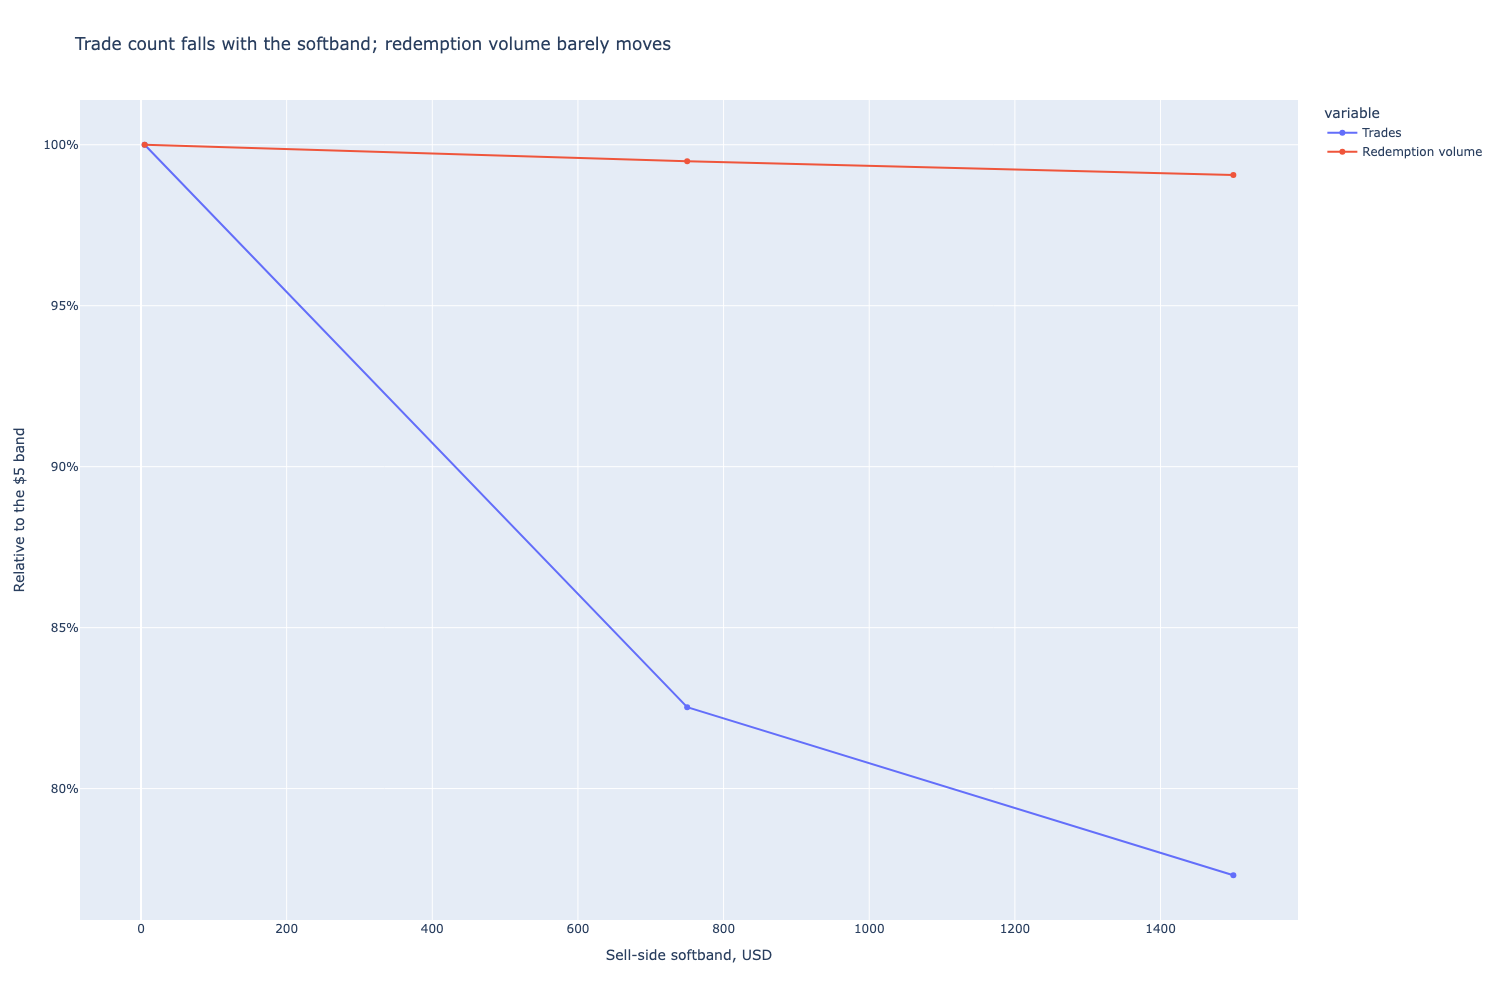

In [21]:
import re
import traceback

from tradeexecutor.backtest.backtest_execution import BacktestExecutionFailed
from tradeexecutor.strategy.parameters import StrategyParameters

# The 25,000 run swept $5, $125, $250, $500, $750, $1,000 and $2,000, i.e. the hard floor plus
# 0.5%, 1%, 2%, 3%, 4% and 8% of capital. Hold those *relative* rungs fixed here so the two runs
# compare rung for rung: an absolute band suppresses relatively smaller trims as capital grows, so
# reusing the same dollar values would confound band width with bankroll size.
#
# The first rung stays at the $5 Hyperliquid hard minimum - it is "no band", not a percentage.
SOFTBAND_RUNGS_PCT = [0.005, 0.01, 0.02, 0.04]
SOFTBAND_LADDER = [Parameters.absolute_min_vault_deposit_usd] + [
    round(Parameters.initial_cash * pct, 2) for pct in SOFTBAND_RUNGS_PCT
]
print("Softband ladder:", ", ".join(f"${b:,.0f}" for b in SOFTBAND_LADDER))
print("as % of capital:", ", ".join(
    f"{b / Parameters.initial_cash:.2%}" for b in SOFTBAND_LADDER))


def run_softband(band_usd, start_at=None, end_at=None):
    """Run the release-candidate configuration at one sell-side threshold.

    Returns a metrics row. A configuration that cannot complete a backtest is recorded with
    ``Crashed`` set and whatever the engine reported, rather than aborting the notebook: a band
    that crashes is a result about that band.
    """
    label = f"${band_usd:,.0f} band"
    apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)
    run_parameters = StrategyParameters.from_dict(dict(parameters))
    run_parameters["sell_rebalance_min_threshold_usd"] = band_usd

    try:
        variant_result = run_backtest_inline(
            name=label,
            engine_version="0.5",
            decide_trades=decide_trades,
            indicator_combinations=indicator_data.indicator_combinations,
            cycle_duration=Parameters.cycle_duration,
            client=client,
            universe=strategy_universe,
            parameters=run_parameters,
            max_workers=1,
            start_at=start_at or Parameters.backtest_start,
            end_at=end_at or Parameters.backtest_end,
        )
    except BacktestExecutionFailed:
        # `str(exc)` carries only the generic "not enough cash" summary; the cycle and the exact
        # shortfall live in the chained OutOfSimulatedBalance, so read the formatted traceback.
        detail = traceback.format_exc()
        cycle_match = re.search(r"failed on strategy cycle ([0-9-]+ [0-9:]+)", detail)
        shortfall_match = re.search(r"went negative (-?[0-9.]+)", detail)
        failed_at = cycle_match.group(1) if cycle_match else "unknown"
        shortfall = float(shortfall_match.group(1)) if shortfall_match else float("nan")
        print(f"  {label}: CRASHED at {failed_at}, short ${abs(shortfall):,.2f}")
        return {
            "Band": band_usd,
            "Run": label,
            "Crashed": True,
            "Failed at": failed_at,
            "Shortfall USD": shortfall,
        }

    variant_state = variant_result.state
    variant_equity = calculate_equity_curve(variant_state)
    trades = list(variant_state.portfolio.get_all_trades())
    sells = [t for t in trades if t.pair.is_vault() and t.is_sell() and t.is_success()]
    exits = [t for t in sells if t.closing]
    trims = [t for t in sells if not t.closing]
    sell_volume = sum(abs(float(t.get_value() or 0.0)) for t in sells)
    exit_volume = sum(abs(float(t.get_value() or 0.0)) for t in exits)

    row = summarise_run(label, variant_equity, variant_state)
    row.update({
        "Band": band_usd,
        "Crashed": False,
        "Failed at": None,
        "Shortfall USD": None,
        "Vault sells": len(sells),
        "Exits": len(exits),
        "Trims": len(trims),
        "Redemption volume": sell_volume,
        "Exit share of volume": exit_volume / sell_volume if sell_volume else float("nan"),
        "Turnover x capital": sell_volume / Parameters.initial_cash,
        "Fee paid": sell_volume * Parameters.vault_redemption_fee / (1.0 - Parameters.vault_redemption_fee),
    })
    return row


sweep_rows = []
for band in SOFTBAND_LADDER:
    print(f"Running ${band:,.0f} band ...")
    sweep_rows.append(run_softband(band))

apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)

sweep_df = pd.DataFrame(sweep_rows).set_index("Run")
crashed = sweep_df[sweep_df["Crashed"]]
survived = sweep_df[~sweep_df["Crashed"]].copy()

if len(crashed):
    print(f"\n{len(crashed)} of {len(sweep_df)} bands could not complete a backtest:")
    crashed = crashed.assign(**{"Band % of capital": crashed["Band"] / Parameters.initial_cash})
    display(crashed[["Band", "Band % of capital", "Failed at", "Shortfall USD"]].style.format({
        "Band": "${:,.0f}", "Band % of capital": "{:.2%}", "Shortfall USD": "${:,.2f}",
    }, na_rep="-").set_caption("Failure boundary: where a wide band outruns the cash it raised"))

display(survived[[
    "Band", "Final equity", "CAGR", "Sharpe", "Max drawdown", "Trades",
    "Vault sells", "Exits", "Trims", "Redemption volume", "Exit share of volume",
    "Turnover x capital", "Fee paid",
]].style.format({
    "Band": "${:,.0f}",
    "Final equity": "${:,.0f}",
    "CAGR": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Max drawdown": "{:.2%}",
    "Trades": "{:.0f}",
    "Vault sells": "{:.0f}",
    "Exits": "{:.0f}",
    "Trims": "{:.0f}",
    "Redemption volume": "${:,.0f}",
    "Exit share of volume": "{:.1%}",
    "Turnover x capital": "{:.1f}x",
    "Fee paid": "${:,.0f}",
}).set_caption("Softband sweep at a 2-day cadence, 33% concentration, 10 BPS"))

# The structural question: does suppressing trades suppress the volume that pays the fee?
if len(survived) > 1:
    base = survived.iloc[0]
    decomposition = pd.DataFrame([{
        "Band": row["Band"],
        "Trades removed vs $5": row["Trades"] / base["Trades"] - 1.0,
        "Trims removed vs $5": row["Trims"] / base["Trims"] - 1.0,
        "Volume removed vs $5": row["Redemption volume"] / base["Redemption volume"] - 1.0,
        "Fee saved vs $5": base["Fee paid"] - row["Fee paid"],
        "CAGR delta vs $5": row["CAGR"] - base["CAGR"],
    } for _, row in survived.iterrows()]).set_index("Band")
    display(decomposition.style.format({
        "Trades removed vs $5": "{:+.1%}",
        "Trims removed vs $5": "{:+.1%}",
        "Volume removed vs $5": "{:+.1%}",
        "Fee saved vs $5": "${:+,.0f}",
        "CAGR delta vs $5": "{:+.2%}",
    }).set_caption(
        "A band that removes many trades but little volume cannot save fee: the fee is charged on "
        "volume, and volume is dominated by large trades the band never touches."
    ))

    fig = px.line(
        survived.set_index("Band")[["Trades", "Redemption volume"]].apply(lambda s: s / s.iloc[0]),
        title="Trade count falls with the softband; redemption volume barely moves",
        markers=True,
    )
    fig.update_yaxes(title="Relative to the $5 band", tickformat=".0%")
    fig.update_xaxes(title="Sell-side softband, USD")
    fig.show()


# Vault price data coverage

Every metric above assumes the daily candle series carries a daily price. It does not, for the first
half of this window. The scanner behind `vault-price-history.parquet` sampled Hypercore vaults
**weekly** until mid-January 2026 and daily afterwards, and `load_partial_data()` forward-fills the
gaps, so a stale price is indistinguishable from an unchanged one inside the backtest.

This cell measures it from the raw parquet rather than taking it on trust.


Measuring coverage for 331 vault pairs in the strategy universe


Chains represented: [9999]


,days,days_with_data,mean_vaults_reporting,Coverage
timestamp,,,,
2026-01-01 00:00:00,25,17,84,68%
2026-02-01 00:00:00,28,28,186,100%
2026-03-01 00:00:00,31,31,241,100%
2026-04-01 00:00:00,30,30,256,100%
2026-05-01 00:00:00,31,31,266,100%
2026-06-01 00:00:00,30,30,281,100%
2026-07-01 00:00:00,9,9,286,100%


Days in window: 184   days with no price data at all: 8 (4%)
Median gap between data days before 2026-01-17: 7 days
Median gap between data days after  2026-01-17: 1 days
Daily-resolution sub-window: 2026-01-17 to 2026-07-10


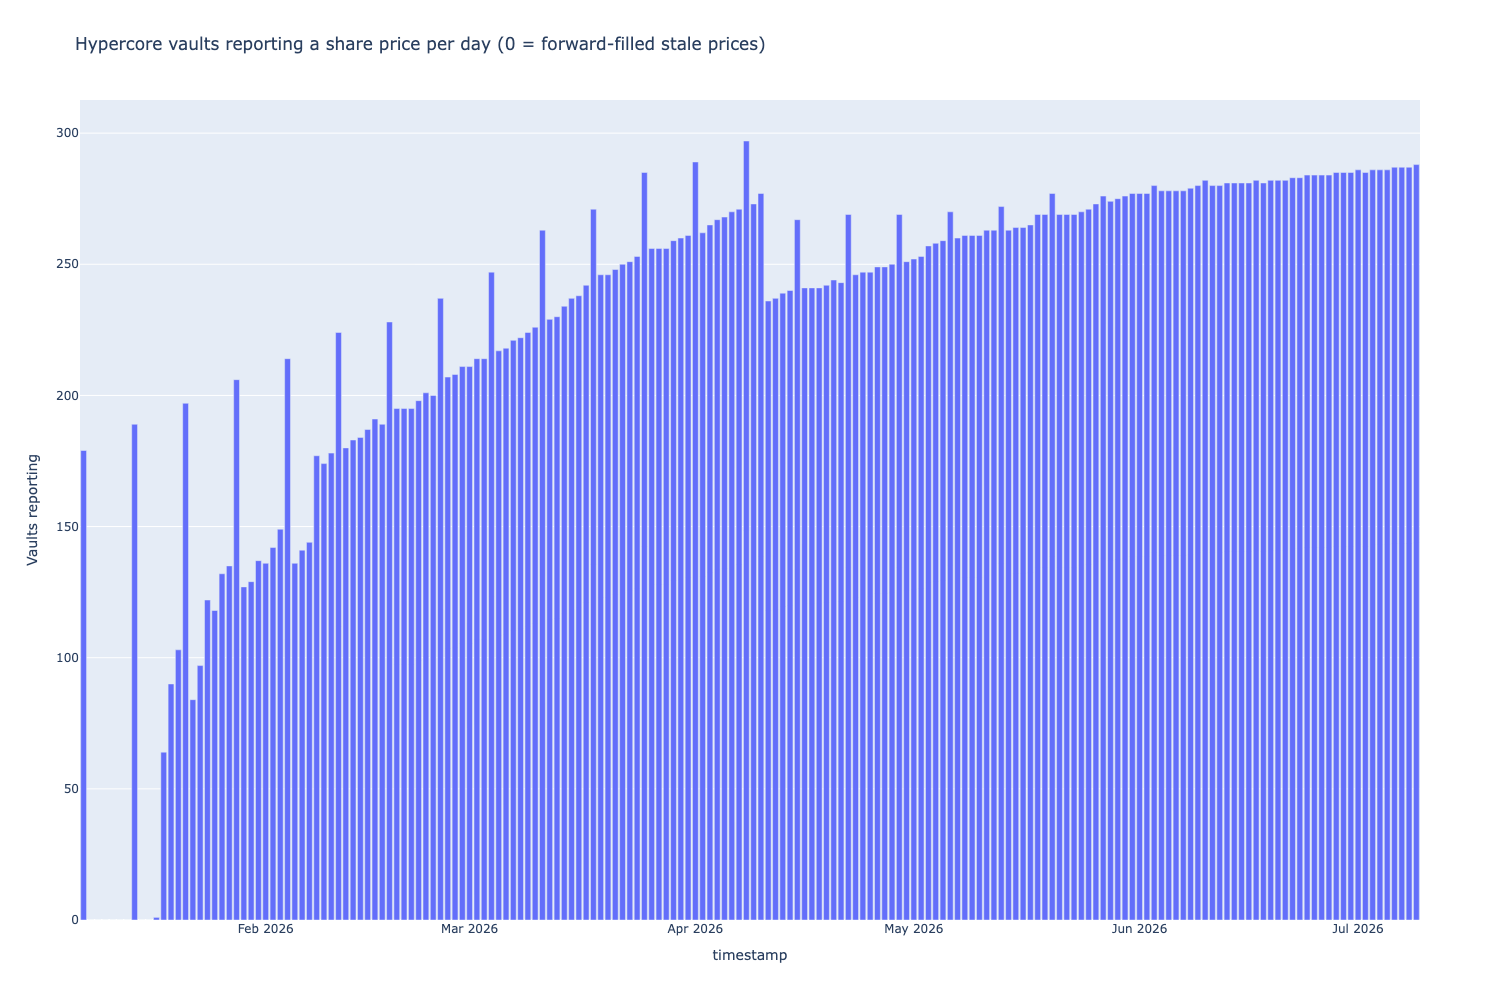

In [22]:
from pathlib import Path

VAULT_PRICE_PARQUET = Path.home() / ".cache/tradingstrategy/vaults/downloads/vault-price-history.parquet"

# Measure the vaults this strategy actually trades, identified by address.
#
# Do NOT filter on `CHAIN_ID`: it is `ChainId.hyperliquid` (999, HyperEVM), while the tradeable
# vaults are Hypercore vaults on chain 9999. Filtering on 999 selects a different, fully covered
# set of vaults and reports 0% missing data.
traded_vault_addresses = {
    pair.pool_address.lower()
    for pair in strategy_universe.iterate_pairs()
    if pair.is_vault() and pair.pool_address
}
print(f"Measuring coverage for {len(traded_vault_addresses)} vault pairs in the strategy universe")

# `timestamp` is the parquet index, not a column.
coverage_raw = pd.read_parquet(VAULT_PRICE_PARQUET, columns=["chain", "address"]).reset_index()
coverage_raw = coverage_raw[coverage_raw["address"].str.lower().isin(traded_vault_addresses)]
coverage_raw = coverage_raw[
    (coverage_raw["timestamp"] >= Parameters.backtest_start)
    & (coverage_raw["timestamp"] < Parameters.backtest_end)
]
print(f"Chains represented: {sorted(coverage_raw['chain'].unique().tolist())}")

vaults_per_day = coverage_raw.set_index("timestamp").resample("1D")["address"].nunique()

coverage_by_month = vaults_per_day.groupby(pd.Grouper(freq="MS")).agg(
    days="size",
    days_with_data=lambda s: int((s > 0).sum()),
    mean_vaults_reporting="mean",
)
coverage_by_month["Coverage"] = coverage_by_month["days_with_data"] / coverage_by_month["days"]
display(coverage_by_month.style.format({
    "mean_vaults_reporting": "{:.0f}",
    "Coverage": "{:.0%}",
}).set_caption("Days on which any Hypercore vault reported a share price"))

data_days = vaults_per_day[vaults_per_day > 0].index

# The first date from which coverage stays daily for at least a fortnight.
DAILY_DATA_START = None
for offset in range(len(data_days) - 14):
    window_gaps = pd.Series(data_days[offset:offset + 14]).diff().dt.days.fillna(1)
    if (window_gaps == 1).all():
        DAILY_DATA_START = data_days[offset]
        break

assert DAILY_DATA_START is not None, "Never found a fortnight of continuous daily coverage"
assert DAILY_DATA_START > Parameters.backtest_start, (
    f"Daily coverage starts at the window start ({DAILY_DATA_START}), so the sub-window test below "
    f"would just repeat the full window - check that the address filter selected the traded vaults"
)

blank_days = int((vaults_per_day == 0).sum())
print(f"Days in window: {len(vaults_per_day)}   days with no price data at all: {blank_days} ({blank_days/len(vaults_per_day):.0%})")
print(f"Median gap between data days before {DAILY_DATA_START.date()}: "
      f"{pd.Series(data_days[data_days < DAILY_DATA_START]).diff().dt.days.median():.0f} days")
print(f"Median gap between data days after  {DAILY_DATA_START.date()}: "
      f"{pd.Series(data_days[data_days >= DAILY_DATA_START]).diff().dt.days.median():.0f} days")
print(f"Daily-resolution sub-window: {DAILY_DATA_START.date()} to {Parameters.backtest_end.date()}")

fig = px.bar(
    vaults_per_day,
    title="Hypercore vaults reporting a share price per day (0 = forward-filled stale prices)",
)
fig.update_layout(showlegend=False)
fig.update_yaxes(title="Vaults reporting")
fig.show()


# The sweep repeated on daily-resolution data only

The vault feed is sampled weekly until 2026-01-17. This window starts on 2026-01-01, so its opening
fortnight is partly forward-filled. Repeating the sweep from 2026-01-17 shows whether the softband
conclusions depend on that fortnight.


In [23]:
sub_sweep_rows = []
for band in SOFTBAND_LADDER:
    print(f"Running ${band:,.0f} band on the daily-data sub-window ...")
    sub_sweep_rows.append(run_softband(
        band,
        start_at=DAILY_DATA_START.to_pydatetime(),
        end_at=Parameters.backtest_end,
    ))

apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)

sub_sweep_df = pd.DataFrame(sub_sweep_rows).set_index("Run")
sub_crashed = sub_sweep_df[sub_sweep_df["Crashed"]]
sub_survived = sub_sweep_df[~sub_sweep_df["Crashed"]]

if len(sub_crashed):
    print(f"{len(sub_crashed)} band(s) crashed on the sub-window: "
          f"{[f'${b:,.0f}' for b in sub_crashed['Band']]}")

display(sub_survived[[
    "Band", "Final equity", "CAGR", "Sharpe", "Max drawdown", "Trades",
    "Trims", "Redemption volume", "Turnover x capital", "Fee paid",
]].style.format({
    "Band": "${:,.0f}",
    "Final equity": "${:,.0f}",
    "CAGR": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Max drawdown": "{:.2%}",
    "Trades": "{:.0f}",
    "Trims": "{:.0f}",
    "Redemption volume": "${:,.0f}",
    "Turnover x capital": "{:.1f}x",
    "Fee paid": "${:,.0f}",
}).set_caption(
    f"Softband sweep, daily-resolution sub-window ({DAILY_DATA_START.date()} to {Parameters.backtest_end.date()})"
))

# Does the failure boundary move with the window?
full_boundary = [b for b, c in zip(sweep_df["Band"], sweep_df["Crashed"]) if c]
sub_boundary = [b for b, c in zip(sub_sweep_df["Band"], sub_sweep_df["Crashed"]) if c]
print(f"\nBands that crash on the full window:      {[f'${b:,.0f}' for b in full_boundary] or 'none'}")
print(f"Bands that crash on the daily sub-window: {[f'${b:,.0f}' for b in sub_boundary] or 'none'}")
print("A boundary that moves with the window is a property of the data, not of the threshold.")


Running $5 band on the daily-data sub-window ...


Running $750 band on the daily-data sub-window ...


Running $1,500 band on the daily-data sub-window ...


Running $3,000 band on the daily-data sub-window ...


  $3,000 band: CRASHED at 2026-03-04 00:00:00, short $1,908.67
Running $6,000 band on the daily-data sub-window ...


  $6,000 band: CRASHED at 2026-01-19 00:00:00, short $2,989.27
2 band(s) crashed on the sub-window: ['$3,000', '$6,000']


,Band,Final equity,CAGR,Sharpe,Max drawdown,Trades,Trims,Redemption volume,Turnover x capital,Fee paid
Run,,,,,,,,,,
$5 band,$5,"$163,201",19.85%,1.06,-9.64%,476,167,"$1,614,664",10.8x,"$1,616"
$750 band,$750,"$163,174",19.81%,1.06,-9.65%,392,91,"$1,606,353",10.7x,"$1,608"
"$1,500 band","$1,500","$162,964",19.48%,1.04,-9.70%,364,70,"$1,598,999",10.7x,"$1,601"



Bands that crash on the full window:      ['$3,000', '$6,000']
Bands that crash on the daily sub-window: ['$3,000', '$6,000']
A boundary that moves with the window is a property of the data, not of the threshold.


# Capital or cap? A 2x2 to separate them

This notebook changed two things at once against NB66 - capital 75,000 -> 150,000 and pool cap
15% -> 25% - so the headline difference cannot be attributed to either on its own. This cell runs
the four corners at a fixed 0.5% softband and 2-day cadence.

The buy threshold and the softband are both derived from capital, so they are scaled with it here;
otherwise a bigger bankroll would silently trade against a relatively finer threshold and the
comparison would not be clean.


In [24]:
def run_capacity(label, capital, pool_cap):
    """Run one (capital, pool cap) corner, scaling every capital-derived threshold with it."""
    apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)
    run_parameters = StrategyParameters.from_dict(dict(parameters))
    run_parameters["initial_cash"] = capital
    run_parameters["per_position_cap_of_pool_pct"] = pool_cap
    run_parameters["individual_rebalance_min_threshold_usd"] = max(
        Parameters.absolute_min_vault_deposit_usd,
        capital * Parameters.individual_rebalance_min_threshold_of_initial_cash_pct,
    )
    run_parameters["sell_rebalance_min_threshold_usd"] = capital * 0.005

    try:
        capacity_result = run_backtest_inline(
            name=label,
            engine_version="0.5",
            decide_trades=decide_trades,
            indicator_combinations=indicator_data.indicator_combinations,
            cycle_duration=Parameters.cycle_duration,
            client=client,
            universe=strategy_universe,
            parameters=run_parameters,
            max_workers=1,
            start_at=Parameters.backtest_start,
            end_at=Parameters.backtest_end,
            initial_deposit=capital,
        )
    except BacktestExecutionFailed:
        print(f"  {label}: CRASHED")
        return {"Run": label, "Capital": capital, "Pool cap": pool_cap, "Crashed": True}

    capacity_state = capacity_result.state
    capacity_equity = calculate_equity_curve(capacity_state)
    returns = calculate_returns(capacity_equity).resample("1D").sum(min_count=1).fillna(0.0).dropna()
    cagr = float(calculate_cagr(returns))

    allocation_df = extract_allocation_df(capacity_state)
    sells = [t for t in capacity_state.portfolio.get_all_trades()
             if t.pair.is_vault() and t.is_sell() and t.is_success()]
    volume = sum(abs(float(t.get_value() or 0.0)) for t in sells)


    # Accounting integrity (NB74). Confirms the books balance for this run:
    #   final equity == initial cash + realised + unrealised - redemption fees
    # The fee is not booked into realised P&L, so it is added back before comparing.
    _pf = capacity_state.portfolio
    _realised = sum(float(x.get_realised_profit_usd() or 0) for x in _pf.get_all_positions())
    _unrealised = sum(float(x.get_unrealised_profit_usd() or 0)
                      for x in _pf.open_positions.values() if not x.is_credit_supply())
    _sells = [t for t in _pf.get_all_trades() if t.pair.is_vault() and t.is_sell() and t.is_success()]
    _volume = sum(abs(float(t.executed_reserve or 0)) for t in _sells)
    _fee = _volume * Parameters.vault_redemption_fee / (1.0 - Parameters.vault_redemption_fee)
    _expected = capital + _realised + _unrealised
    _gap = (float(_pf.get_total_equity()) - _expected) / capital
    _zero_proceeds = sum(
        1 for p in _pf.get_all_positions()
        if p.closed_at is not None and not p.is_credit_supply()
        and sum(abs(float(t.executed_reserve or 0)) for t in p.trades.values() if t.is_buy() and t.is_success()) > 100
        and sum(abs(float(t.executed_reserve or 0)) for t in p.trades.values() if t.is_sell() and t.is_success()) < 1.0
    )

    return {
        "Run": label,
        "Capital": capital,
        "Pool cap": pool_cap,
        "Crashed": False,
        "Unexplained %": _gap,
        "Coherent": abs(_gap) <= 0.01,
        "Destroyed positions": _zero_proceeds,
        "Final equity": float(capacity_equity.iloc[-1]),
        "Cumulative return": float(capacity_equity.iloc[-1] / capital - 1.0),
        "CAGR": cagr,
        "Sharpe": float(calculate_sharpe(returns, periods=365)),
        "Max drawdown": float(calculate_max_drawdown(returns)),
        "Mean cash %": float(allocation_df["cash_pct"].mean()) if "cash_pct" in allocation_df else float("nan"),
        "Mean pool-capped signals": float(allocation_df["capped_by_pool_size"].mean()) if "capped_by_pool_size" in allocation_df else float("nan"),
        "Turnover x capital": volume / capital,
    }


capacity_rows = []
for cap_label, cap_capital, cap_pool in [
    ("75k, 15% cap (NB66 baseline)", 75_000, 0.15),
    ("75k, 25% cap", 75_000, 0.25),
    ("150k, 15% cap", 150_000, 0.15),
    ("150k, 25% cap (this notebook)", 150_000, 0.25),
]:
    print(f"Running {cap_label} ...")
    capacity_rows.append(run_capacity(cap_label, cap_capital, cap_pool))

apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)

capacity_df = pd.DataFrame(capacity_rows).set_index("Run")
display(capacity_df.drop(columns=["Crashed"]).style.format({
    "Capital": "${:,.0f}",
    "Pool cap": "{:.0%}",
    "Final equity": "${:,.0f}",
    "Cumulative return": "{:.2%}",
    "CAGR": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Max drawdown": "{:.2%}",
    "Mean cash %": "{:.2f}",
    "Mean pool-capped signals": "{:.2f}",
    "Turnover x capital": "{:.1f}x",
    "Unexplained %": "{:.2%}",
    "Destroyed positions": "{:.0f}",
}, na_rep="-").set_caption("Capital x pool cap, 0.5% softband, 2-day cadence, 10 BPS"))

incoherent_cells = [r for r in capacity_rows if not r.get("Crashed") and not r.get("Coherent", True)]
if incoherent_cells:
    print(f"WARNING: {len(incoherent_cells)} cell(s) fail the accounting identity - results not trustworthy")
else:
    print("All cells satisfy the accounting identity: equity reconciles with position P&L.")

look = {r["Run"]: r for r in capacity_rows if not r.get("Crashed")}
if len(look) == 4:
    a = look["75k, 15% cap (NB66 baseline)"]["CAGR"]
    b = look["75k, 25% cap"]["CAGR"]
    c = look["150k, 15% cap"]["CAGR"]
    d = look["150k, 25% cap (this notebook)"]["CAGR"]
    print(f"\nCAGR attribution:")
    print(f"  raising the pool cap at 75k:    {b - a:+.2%}")
    print(f"  raising the pool cap at 150k:   {d - c:+.2%}")
    print(f"  doubling capital at a 15% cap:  {c - a:+.2%}")
    print(f"  doubling capital at a 25% cap:  {d - b:+.2%}")
    print(f"  both together:                  {d - a:+.2%}")
    print("\nIf the capital rows dominate the cap rows, the universe is the constraint and a "
          "looser cap cannot buy much headroom.")


Running 75k, 15% cap (NB66 baseline) ...


Running 75k, 25% cap ...


Running 150k, 15% cap ...


Running 150k, 25% cap (this notebook) ...


,Capital,Pool cap,Unexplained %,Coherent,Destroyed positions,Final equity,Cumulative return,CAGR,Sharpe,Max drawdown,Mean cash %,Mean pool-capped signals,Turnover x capital
Run,,,,,,,,,,,,,
"75k, 15% cap (NB66 baseline)","$75,000",15%,-0.00%,True,0,"$85,923",14.56%,30.46%,1.55,-9.19%,-,3.05,12.1x
"75k, 25% cap","$75,000",25%,0.00%,True,0,"$88,563",18.08%,38.35%,1.76,-7.97%,-,1.75,13.2x
"150k, 15% cap","$150,000",15%,-0.00%,True,0,"$154,456",2.97%,6.05%,0.41,-13.45%,-,3.80,9.0x
"150k, 25% cap (this notebook)","$150,000",25%,0.00%,True,0,"$166,304",10.87%,22.41%,1.19,-9.83%,-,3.31,11.5x


All cells satisfy the accounting identity: equity reconciles with position P&L.

CAGR attribution:
  raising the pool cap at 75k:    +7.90%
  raising the pool cap at 150k:   +16.36%
  doubling capital at a 15% cap:  -24.41%
  doubling capital at a 25% cap:  -15.94%
  both together:                  -8.04%

If the capital rows dominate the cap rows, the universe is the constraint and a looser cap cannot buy much headroom.


# Why the softband cannot reach the fee

The fee is charged on redemption *volume*. This cell splits that volume into full exits and partial
trims at the headline band, because the softband only ever suppresses trims - and only the small
ones.


In [25]:
structure_rows = []
for _, row in survived.iterrows():
    structure_rows.append({
        "Band": row["Band"],
        "Exits": row["Exits"],
        "Trims": row["Trims"],
        "Exit share of volume": row["Exit share of volume"],
        "Trim share of volume": 1.0 - row["Exit share of volume"],
        "Fee paid": row["Fee paid"],
        "Fee attributable to exits": row["Fee paid"] * row["Exit share of volume"],
    })

structure_df = pd.DataFrame(structure_rows).set_index("Band")
display(structure_df.style.format({
    "Exits": "{:.0f}",
    "Trims": "{:.0f}",
    "Exit share of volume": "{:.1%}",
    "Trim share of volume": "{:.1%}",
    "Fee paid": "${:,.0f}",
    "Fee attributable to exits": "${:,.0f}",
}).set_caption("Where the redemption fee is actually paid"))

widest = survived.iloc[-1]
narrowest = survived.iloc[0]
print(f"At the widest band that completes (${widest['Band']:,.0f}): "
      f"{widest['Exits']:.0f} exits carry {widest['Exit share of volume']:.1%} of redemption volume, "
      f"so ${widest['Fee paid'] * widest['Exit share of volume']:,.0f} of the "
      f"${widest['Fee paid']:,.0f} fee is untouchable by any trim threshold.")
print(f"Widening $5 -> ${widest['Band']:,.0f} removes "
      f"{1 - widest['Trims'] / narrowest['Trims']:.0%} of trims and "
      f"{1 - widest['Redemption volume'] / narrowest['Redemption volume']:.1%} of volume.")


,Exits,Trims,Exit share of volume,Trim share of volume,Fee paid,Fee attributable to exits
Band,,,,,,
5.000000,70,171,69.3%,30.7%,"$1,740","$1,206"
750.000000,70,92,69.8%,30.2%,"$1,731","$1,208"
1500.000000,70,71,70.3%,29.7%,"$1,724","$1,211"


At the widest band that completes ($1,500): 70 exits carry 70.3% of redemption volume, so $1,211 of the $1,724 fee is untouchable by any trim threshold.
Widening $5 -> $1,500 removes 58% of trims and 0.9% of volume.


# Robustness diagnostics

In [26]:
from tradeexecutor.statistics.key_metric import (
    calculate_cagr,
    calculate_max_drawdown,
    calculate_sharpe,
    calculate_sortino,
)
from tradeexecutor.curator import is_quarantined


def return_metrics(return_series: pd.Series) -> dict:
    return_series = return_series.dropna()
    cagr = float(calculate_cagr(return_series))
    max_drawdown = float(calculate_max_drawdown(return_series))
    return {
        'Cumulative return': float((1.0 + return_series).prod() - 1.0),
        'CAGR': cagr,
        'Sharpe': float(calculate_sharpe(return_series, periods=365)),
        'Sortino': float(calculate_sortino(return_series, periods=365)),
        'Max drawdown': max_drawdown,
    }


daily_returns = calculate_returns(equity).resample('1D').sum(min_count=1).fillna(0.0)
profitable_returns = daily_returns[daily_returns > 0.0]
profitable_outlier_cutoff = profitable_returns.quantile(0.95)
profitable_outlier_mask = (daily_returns > 0.0) & (daily_returns > profitable_outlier_cutoff)
returns_without_best_days = daily_returns.mask(profitable_outlier_mask, 0.0)

robustness_df = pd.DataFrame([
    {'Scenario': 'Original', **return_metrics(daily_returns)},
    {
        'Scenario': 'Largest 5% profitable daily returns neutralised',
        **return_metrics(returns_without_best_days),
    },
]).set_index('Scenario')
display(robustness_df.style.format({
    'Cumulative return': '{:.2%}',
    'CAGR': '{:.2%}',
    'Sharpe': '{:.2f}',
    'Sortino': '{:.2f}',
    'Max drawdown': '{:.2%}',
}))

best_day = pd.Timestamp(daily_returns.idxmax()).normalize()
daily_return_diagnostics_df = pd.DataFrame([{
    'Best day': best_day,
    'Best-day return': float(daily_returns.max()),
    'Worst day': pd.Timestamp(daily_returns.idxmin()).normalize(),
    'Worst-day return': float(daily_returns.min()),
    'Best-day share of positive daily returns': float(daily_returns.max() / profitable_returns.sum()),
    'Daily-return skew': float(daily_returns.skew()),
    'Daily excess kurtosis': float(daily_returns.kurtosis()),
    'Neutralised profitable days': int(profitable_outlier_mask.sum()),
    'Neutralisation cutoff': float(profitable_outlier_cutoff),
}])
display(daily_return_diagnostics_df.style.format({
    'Best-day return': '{:.2%}',
    'Worst-day return': '{:.2%}',
    'Best-day share of positive daily returns': '{:.1%}',
    'Daily-return skew': '{:.2f}',
    'Daily excess kurtosis': '{:.2f}',
    'Neutralisation cutoff': '{:.2%}',
}))

valuation_rows = []
for position in positions:
    for update in position.valuation_updates:
        valuation_day = pd.Timestamp(update.valued_at).normalize()
        if valuation_day != best_day or update.old_value is None:
            continue
        valuation_rows.append({
            'Vault': position.pair.base.token_symbol,
            'Vault address': position.pair.pool_address,
            'Valuation change USD': float(update.new_value - update.old_value),
            'Curator-quarantined on best day': is_quarantined(
                position.pair.pool_address,
                best_day.to_pydatetime(),
            ),
        })

best_day_valuation_df = pd.DataFrame(valuation_rows)
if len(best_day_valuation_df):
    best_day_valuation_df = best_day_valuation_df.sort_values('Valuation change USD', ascending=False)
display(best_day_valuation_df.head(12).style.format({'Valuation change USD': '${:,.0f}'}))



from tradeexecutor.curator.curator import QUARANTINE_PERIODS

quarantine_overlap_rows = []
for position in positions:
    position_address = position.pair.pool_address.lower()
    position_end = position.closed_at or Parameters.backtest_end
    for address, quarantine_start, quarantine_end, reason in QUARANTINE_PERIODS:
        if position_address != address.lower():
            continue
        if position.opened_at <= quarantine_end and position_end >= quarantine_start:
            quarantine_overlap_rows.append({
                'Vault': position.pair.base.token_symbol,
                'Opened': position.opened_at,
                'Closed': position.closed_at,
                'Quarantine start': quarantine_start,
                'Quarantine end': quarantine_end,
                'Realised profit USD': float(position.get_realised_profit_usd() or 0.0),
                'Reason': reason,
            })

quarantine_overlap_df = pd.DataFrame(quarantine_overlap_rows)
display(quarantine_overlap_df.style.format({'Realised profit USD': '${:,.0f}'}).set_caption('Curator quarantine overlap audit'))



best_day_position_rows = []
for position in positions:
    position_end = position.closed_at or Parameters.backtest_end
    if not (position.opened_at <= best_day.to_pydatetime() <= position_end):
        continue
    candles = strategy_universe.data_universe.candles.get_candles_by_pair(position.pair.internal_id)
    candle_closes = candles.set_index('timestamp')['close'].sort_index()
    # The equity curve is sampled once per strategy cycle, so on a 2-day cadence the "best day"
    # booked a two-day move. Measure each vault over the same span - comparing against yesterday's
    # close attributes only the final day and can show every holding flat while the portfolio jumps.
    equity_sample_days = pd.DatetimeIndex(equity.index).normalize()
    earlier_samples = equity_sample_days[equity_sample_days < best_day]
    span_start = earlier_samples[-1] if len(earlier_samples) else best_day - pd.Timedelta(days=1)
    close_on_best_day = candle_closes.loc[candle_closes.index <= best_day].iloc[-1]
    close_before_best_day = candle_closes.loc[candle_closes.index <= span_start].iloc[-1]
    best_day_position_rows.append({
        'Vault': position.pair.base.token_symbol,
        'Position opened': position.opened_at,
        'Position closed': position.closed_at,
        'Vault return over the best step': float(close_on_best_day / close_before_best_day - 1.0),
        'Realised profit USD': float(position.get_realised_profit_usd() or 0.0),
        'Curator-quarantined on best day': is_quarantined(
            position.pair.pool_address,
            best_day.to_pydatetime(),
        ),
    })

best_day_positions_df = pd.DataFrame(best_day_position_rows).sort_values(
    'Vault return over the best step',
    ascending=False,
)
display(
    best_day_positions_df.style.format({
        'Vault return over the best step': '{:.2%}',
        'Realised profit USD': '${:,.0f}',
    }).set_caption('Position moves on the best portfolio day')
)


,Cumulative return,CAGR,Sharpe,Sortino,Max drawdown
Scenario,,,,,
Original,10.98%,22.41%,1.19,1.77,-9.83%
Largest 5% profitable daily returns neutralised,0.93%,1.81%,0.19,0.26,-9.83%


,Best day,Best-day return,Worst day,Worst-day return,Best-day share of positive daily returns,Daily-return skew,Daily excess kurtosis,Neutralised profitable days,Neutralisation cutoff
0,2026-07-04 00:00:00,3.30%,2026-05-21 00:00:00,-3.62%,6.5%,0.03,4.59,3,3.10%


,Vault,Position opened,Position closed,Vault return over the best step,Realised profit USD,Curator-quarantined on best day
2,Realist Ca,2026-06-24 00:00:00,NaT,4.02%,"$5,386",False
3,Scared Mon,2026-07-02 00:00:00,NaT,3.79%,$0,False
1,Mad Scient,2026-06-22 00:00:00,NaT,3.68%,$0,False
4,DOEZOE,2026-06-30 00:00:00,2026-07-04 00:00:00,1.51%,$-14,False
5,pmalt,2026-07-04 00:00:00,2026-07-06 00:00:00,0.99%,$-22,False
6,Citadel,2026-06-24 00:00:00,2026-07-08 00:00:00,0.00%,$-55,False
0,Goon Edgin,2026-06-20 00:00:00,NaT,-3.32%,$365,False
